# LPT Initial Conditions & Conditional HMF — Tutorial

This notebook validates BEoRN's native LPT initial-conditions engine and the
EPS-based Conditional Halo Mass Function (CHMF).  It is structured as a
tutorial linked from the documentation.

Each section is one physics concept: the concept and its numpy implementation
first, then validation (internal consistency and against `py21cmfast` where
installed), then a **GPU acceleration test** and an **autodiff test**.  The autodiff
tests differentiate the power spectrum *measured from the simulated box* with
respect to the cosmological parameters.  All GPU/autodiff cells degrade
gracefully when JAX/torch or a GPU is unavailable.

**Sections**
1. [Setup and environment detection](#sec1)
2. [Linear power spectrum](#sec2)
3. [Initial conditions of density fields](#sec3)
4. [1LPT / Zel'dovich density field](#sec4)
5. [2LPT density field](#sec5)
6. [Velocity fields](#sec6)
7. [Halo catalogue generation from the conditional HMF](#sec7)


---
<a id="sec1"></a>
## 1. Setup and environment detection

Imports, the fiducial cosmology (Planck 2018 best-fit), and detection of the
optional backends: JAX / torch availability and GPU devices.  The flags set
here (`_JAX`, `_TORCH_AVAILABLE`, `torch_gpu`) drive the GPU and autodiff
subsections of every following section.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import quad

import beorn
from beorn.structs import Parameters
from beorn import lpt
from beorn.cosmo import D

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('beorn version:', beorn.__version__ if hasattr(beorn, '__version__') else 'dev')

beorn version: dev


In [2]:
# Fiducial cosmology — matches Planck 2018 TT,TE,EE+lowE best-fit
param = Parameters()
param.simulation.Ncell = 128                # grid — fast enough for development
param.simulation.Lbox  = 200                # Mpc/h
param.simulation.use_hunits = True          # Lbox above is in Mpc/h, not physical Mpc
param.simulation.oversample = 1             # explicit default: no fine-paint-then-downsample (see LPTBase.get_density)
param.simulation.mass_assignment = 'PCS'
param.simulation.backend.default = 'numpy'  # explicit default: keeps this as the numpy reference used throughout for numpy-vs-jax/torch comparisons below

cosmo = param.cosmology
print(f'Ωm={cosmo.Om}  Ωb={cosmo.Ob}  h={cosmo.h0}  σ₈={cosmo.sigma_8}  ns={cosmo.ns}')

Ωm=0.315  Ωb=0.045  h=0.673  σ₈=0.83  ns=0.96


In [3]:
import time

# ── Optional-dependency and device detection (used by GPU/autodiff cells) ────
try:
    import jax
    import jax.numpy as jnp
    jax.config.update('jax_enable_x64', True)   # float64 (jax default is float32)
    _JAX = True
    print(f'JAX {jax.__version__} — devices: {jax.devices()}')
except ImportError:
    _JAX = False
    print('JAX is not installed — jax autodiff/GPU demos will be skipped.')

try:
    import torch
    _TORCH_AVAILABLE = True
    torch_gpu = ('cuda' if torch.cuda.is_available()
                 else 'mps' if torch.backends.mps.is_available() else None)
    print(f'torch {torch.__version__} — CUDA={torch.cuda.is_available()}  '
          f'MPS={torch.backends.mps.is_available()}  → GPU device: {torch_gpu}')
except ImportError:
    _TORCH_AVAILABLE = False
    torch_gpu = None
    print('torch is not installed — torch autodiff/GPU demos will be skipped.')

if torch_gpu is None:
    print('GPUs not available — GPU cells will report this and continue on CPU.')
if torch_gpu == 'mps':
    print('Note: MPS (Apple GPU) supports float32 only; GPU cells use float32 there.')

def bench(fn, n=5):
    """Best-of-n wall time in seconds; one warm-up call (jit compile, caches)."""
    fn()
    ts = []
    for _ in range(n):
        t0 = time.perf_counter(); fn(); ts.append(time.perf_counter() - t0)
    return min(ts)

JAX 0.10.2 — devices: [CudaDevice(id=0)]
torch 2.13.0+cu130 — CUDA=True  MPS=False  → GPU device: cuda


---
<a id="sec2"></a>
## 2. Linear power spectrum

The linear matter power spectrum $P(k)$ seeds everything downstream: initial
conditions, LPT displacements, and the conditional HMF.  We compare the
Eisenstein & Hu (1998) no-wiggle and wiggle fits at $z = 0$ and check the
shape evolution with redshift.

A detailed presentation of the $P(k)$ / HMF machinery — backends, GPU
execution, and gradients of $P(k)$, $\sigma(M)$, the growth factor and the
HMF — is in [ps_hmf_models.ipynb](ps_hmf_models.ipynb).  Here we only confirm
that the pure function `pk_eh_nowiggle` matches the class implementation and
that its GPU execution and autodiff work.


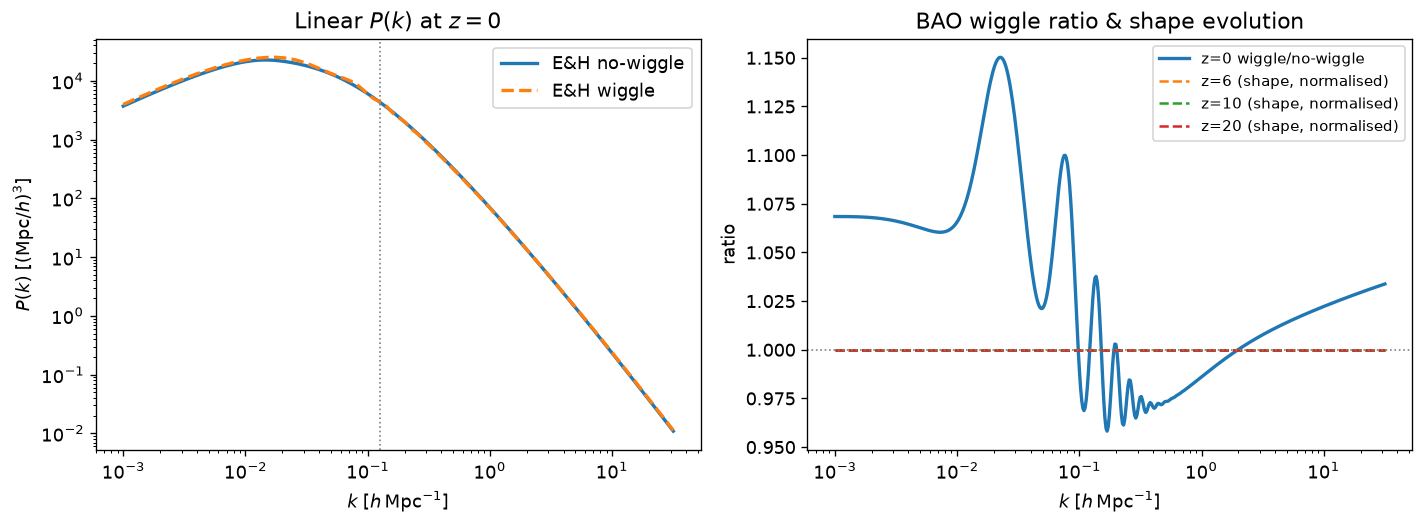

In [4]:
k = np.logspace(-3, 1.5, 500)   # h/Mpc

eh_nw = lpt.EisensteinHu(param, wiggle=False)
eh_w  = lpt.EisensteinHu(param, wiggle=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# --- P(k) at z=0 ---
ax = axes[0]
ax.loglog(k, eh_nw.P(k, z=0), label='E&H no-wiggle', lw=2)
ax.loglog(k, eh_w.P(k,  z=0), label='E&H wiggle',    lw=2, ls='--')
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k)\;[(\mathrm{Mpc}/h)^3]$')
ax.set_title('Linear $P(k)$ at $z=0$')
ax.legend()
ax.axvline(1/8, ls=':', color='grey', lw=1, label=r'$k=1/(8\,h^{-1}\mathrm{Mpc})$')

# --- ratio and redshift evolution ---
ax = axes[1]
ax.semilogx(k, eh_w.P(k, z=0) / eh_nw.P(k, z=0), label='z=0 wiggle/no-wiggle', lw=2)
for z in [6, 10, 20]:
    ratio = eh_w.P(k, z=z) / eh_w.P(k, z=0)
    ax.semilogx(k, ratio / ratio.mean(), ls='--', label=f'z={z} (shape, normalised)')
ax.axhline(1, ls=':', color='grey', lw=1)
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel('ratio')
ax.set_title('BAO wiggle ratio & shape evolution')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [5]:
# ── GPU & autodiff for P(k) (full treatment in ps_hmf_models.ipynb §2) ───────
from beorn.lpt import pk_eh_nowiggle

theta_pk = dict(Om=cosmo.Om, Ob=cosmo.Ob, h0=cosmo.h0, ns=cosmo.ns,
                sigma_8=cosmo.sigma_8)
P_fn = pk_eh_nowiggle(k, 0.0, **theta_pk)
print(f'pk_eh_nowiggle (pure fn) vs EisensteinHu class at z=0: max|ratio-1| = '
      f'{np.max(np.abs(P_fn / eh_nw.P(k, z=0) - 1)):.2e}')

if _JAX:
    dP_ds8 = jax.grad(lambda s8: pk_eh_nowiggle(
        jnp.asarray(k), 0.0, cosmo.Om, cosmo.Ob, cosmo.h0, cosmo.ns, s8,
        backend='jax').sum())(cosmo.sigma_8)
    print(f'd(ΣP)/dσ₈ = {float(dP_ds8):+.4e}   '
          '(differentiable in all 5 cosmological parameters)')
else:
    print('JAX is not installed — P(k) autodiff demo skipped.')

if _TORCH_AVAILABLE and torch_gpu is not None:
    dt_g = torch.float32 if torch_gpu == 'mps' else torch.float64
    kt = torch.as_tensor(k, dtype=dt_g, device=torch_gpu)
    args = [torch.tensor(v, dtype=dt_g, device=torch_gpu) for v in theta_pk.values()]
    P_g = pk_eh_nowiggle(kt, 0.0, *args, backend='torch').cpu().double().numpy()
    print(f'pk_eh_nowiggle on torch {torch_gpu}: max|ratio-1| vs numpy = '
          f'{np.max(np.abs(P_g / P_fn - 1)):.2e}')
else:
    print('GPUs not available — P(k) GPU execution skipped.')

pk_eh_nowiggle (pure fn) vs EisensteinHu class at z=0: max|ratio-1| = 0.00e+00
d(ΣP)/dσ₈ = +7.7987e+06   (differentiable in all 5 cosmological parameters)
pk_eh_nowiggle on torch cuda: max|ratio-1| vs numpy = 6.66e-16


---
<a id="sec3"></a>
## 3. Initial conditions of density fields

Draw a Gaussian realisation from $P(k)$ and compute its power spectrum.
The measured $P(k)$ should match the input (modulo shot noise and aliasing).

BEoRN draws **fixed-amplitude** initial conditions (Angulo & Pontzen 2016) by
default: every mode amplitude is pinned to exactly $\sqrt{P(k)\,V/N^3}$ and
only the random phases are drawn, which eliminates Rayleigh amplitude scatter
and strongly reduces cosmic variance.  **Paired simulations** can also be
run: a negative seed (`seed=-s`) negates the whole noise field, flipping all
phases by $\pi$ so that $\delta_-(\mathbf{k}) = -\delta_+(\mathbf{k})$
exactly — averaging statistics over such a pair suppresses cosmic variance
further.


In [6]:
SEED = 42
za = lpt.ZeldovichApproximation(param, seed=SEED)
delta_k_ic = za.delta_k          # shape (N, N, N//2+1)
N = param.simulation.Ncell
L = param.simulation.Lbox
delta_ic   = np.fft.irfftn(delta_k_ic, s=(N, N, N))

print(f'δ IC:  mean={delta_ic.mean():.3e}  std={delta_ic.std():.4f}')
print(f'Grid: {N}³  Lbox={L} Mpc/h')

[BEoRN LPT] backend → NumpyBackend  (scipy.fft, 288 workers)
δ IC:  mean=0.000e+00  std=2.8120
Grid: 128³  Lbox=200 Mpc/h


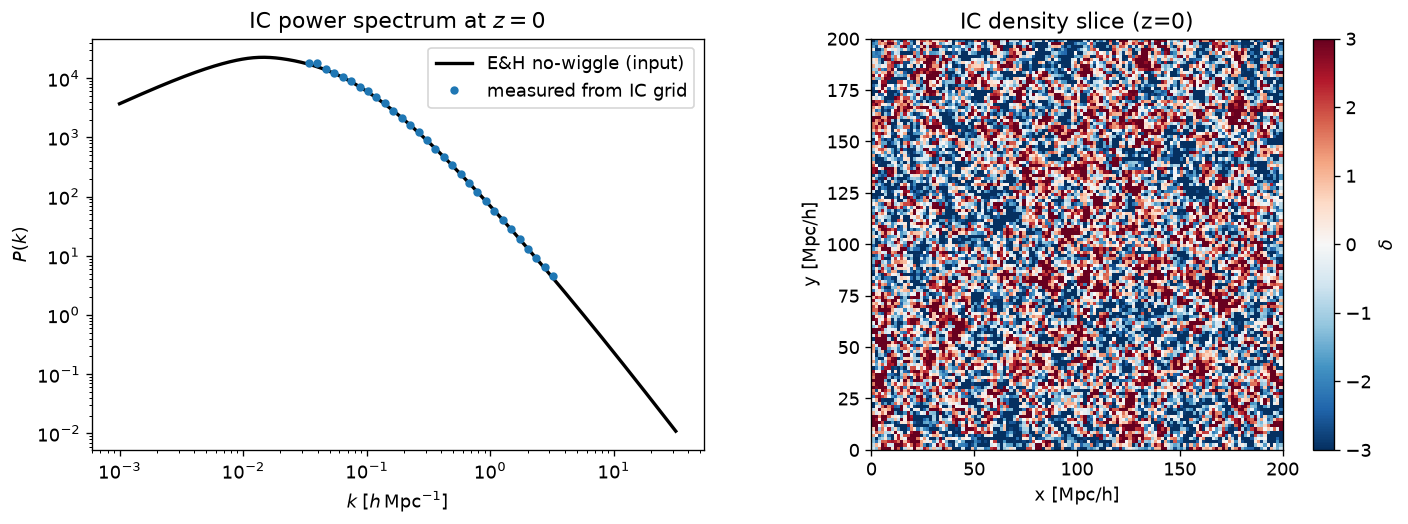

In [7]:
import tools21cm as t2c

# Convenience alias: returns (Pk, k_bins) matching the call pattern used below.
# box_dims in Mpc/h → k_bins in h/Mpc.
def ps1d(delta, Lbox, kbins=30):
    Pk, k = t2c.power_spectrum.power_spectrum_1d(delta, box_dims=Lbox, kbins=kbins)
    return k, Pk

k_meas, Pk_meas = ps1d(delta_ic, param.simulation.Lbox)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.loglog(k, eh_nw.P(k, z=0), 'k-', lw=2, label='E&H no-wiggle (input)')
ax.loglog(k_meas, Pk_meas, 'o', ms=4, label='measured from IC grid')
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k)$')
ax.set_title('IC power spectrum at $z=0$')
ax.legend()

ax = axes[1]
ax.imshow(delta_ic[:, :, param.simulation.Ncell//2],
          origin='lower', cmap='RdBu_r',
          extent=[0, param.simulation.Lbox]*2, vmin=-3, vmax=3)
ax.set_xlabel('x [Mpc/h]')
ax.set_ylabel('y [Mpc/h]')
ax.set_title('IC density slice (z=0)')
plt.colorbar(ax.images[0], ax=ax, label=r'$\delta$')

plt.tight_layout()
plt.show()

### 3.1 Autodiff test: gradients of the measured power spectrum

The differentiability test used throughout this notebook: measure the power
spectrum **of the simulated box** with the differentiable estimator
(`tools21cm.power_spectrum_1d(..., backend='jax')`) and
differentiate it with respect to
$\theta = (\Omega_m, \Omega_b, h_0, n_s, \sigma_8)$.

The white-noise realisation is held **fixed** (θ-independent), so these are
gradients of the *measured* spectrum of one specific box.  A small $32^3$
mini-box keeps each 5-parameter jacobian at a few seconds.  The helpers
defined here (`jac_Phat`, `fd_check`, `plot_dlogP`) are reused by the autodiff
subsections of sections 4–7, which push the ZA, 2LPT, velocity and
halo-mass-grid pipelines through the same measured-$\hat P$ estimator.  One
jax subtlety: the DC-mode amplitude needs the *double-where* trick —
`sqrt(where(dc, 0, P))` has a NaN backward pass, so we substitute 1 inside
the sqrt and zero the result outside.

In the sections that follow, the linear-field gradients computed here are
over-plotted as **dashed lines (same colour)**, so the non-linear (LPT, halo)
gradients can be compared against linear theory at a glance.


In [8]:
if _JAX:
    from beorn.cosmo import growth_factor, growth_rate, hubble_E

    theta_fid = jnp.array([cosmo.Om, cosmo.Ob, cosmo.h0, cosmo.ns, cosmo.sigma_8])
    theta_names = ['Om', 'Ob', 'h0', 'ns', 'sigma_8']

    Nd, Ld, zd = 32, 100.0, 10.0          # differentiable mini-box
    Vd, ad, NKB = Ld**3, 1.0 / (1.0 + zd), 6

    # ── static (θ-independent) geometry ──────────────────────────────────────
    dk_ = 2 * np.pi / Ld
    kxs = (np.fft.fftfreq(Nd, d=1/Nd) * dk_)[:, None, None]
    kys = (np.fft.fftfreq(Nd, d=1/Nd) * dk_)[None, :, None]
    kzs = (np.fft.rfftfreq(Nd, d=1/Nd) * dk_)[None, None, :]
    k2s = kxs**2 + kys**2 + kzs**2
    kmag = np.sqrt(np.where(k2s == 0, 1.0, k2s))
    cell_d = Ld / Nd
    R_cell_d = (3.0 / (4.0 * np.pi))**(1/3) * cell_d
    kRd = kmag * R_cell_d
    Wth_d = np.where(kRd < 1e-3, 1 - kRd**2/10 + kRd**4/280,
                     3.0 * (np.sin(kRd) - kRd*np.cos(kRd)) / kRd**3)
    Wth_d[k2s == 0] = 1.0
    q1 = (np.arange(Nd) + 0.5) * cell_d
    qxd, qyd, qzd = (jnp.asarray(a) for a in np.meshgrid(q1, q1, q1, indexing='ij'))
    kxj, kyj, kzj = jnp.asarray(kxs), jnp.asarray(kys), jnp.asarray(kzs)
    ik2j = jnp.asarray(np.where(k2s == 0, 0.0, 1.0 / k2s))
    dcj, Wthj = jnp.asarray(k2s == 0), jnp.asarray(Wth_d)

    # fixed white-noise realisation (θ-independent)
    noise_kd = jnp.fft.rfftn(jax.random.normal(jax.random.PRNGKey(SEED), (Nd,)*3))

    def delta_k_of(theta):
        """Linear δ(k) at z=zd as a function of the cosmology (fixed noise)."""
        Om, Ob, h0v, nsv, s8v = theta
        Pk = pk_eh_nowiggle(jnp.asarray(kmag), 0.0, Om, Ob, h0v, nsv, s8v,
                            backend='jax')
        amp = jnp.sqrt(jnp.where(dcj, 1.0, Pk) * Nd**3 / Vd)   # double-where
        amp = jnp.where(dcj, 0.0, amp)
        return growth_factor(ad, Om, backend='jax') * noise_kd * amp

    def Phat(field):
        """Measured 1-D power spectrum (differentiable jax estimator)."""
        return t2c.power_spectrum_1d(field, kbins=NKB, box_dims=Ld,
                                     backend='jax')[0]

    def jac_Phat(field_fn):
        """5-parameter jacobian of the measured P̂, plus the fiducial P̂."""
        J  = np.asarray(jax.jacfwd(lambda th: Phat(field_fn(th)))(theta_fid))
        P0 = np.asarray(Phat(field_fn(theta_fid)))
        return J, P0

    def fd_check(field_fn, J, i=4):
        """Max relative error of jacobian column i vs central finite differences."""
        eps = 1e-4 * float(theta_fid[i])
        fd = (np.asarray(Phat(field_fn(theta_fid.at[i].add(eps))))
              - np.asarray(Phat(field_fn(theta_fid.at[i].add(-eps))))) / (2 * eps)
        return float(np.max(np.abs(J[:, i] / fd - 1)))

    def plot_dlogP(ax, J, P0, title, ref=None):
        """∂lnP̂/∂lnθ vs k; ref = linear-field gradients (dashed, same colour)."""
        dlog = J * np.asarray(theta_fid)[None, :] / P0[:, None]
        for i, nm in enumerate(theta_names):
            ax.semilogx(ks_d, dlog[:, i], 'o-', color=f'C{i}', ms=4, lw=1.6,
                        label=fr'$\partial \ln \hat P/\partial \ln \mathrm{{{nm}}}$')
            if ref is not None:
                ax.semilogx(ks_d, ref[:, i], '--', color=f'C{i}', lw=1.2, alpha=0.75)
        ax.axhline(0, color='k', lw=0.8, ls=':')
        ax.set_title(title)
        ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
        ax.set_ylabel(r'$\partial \ln \hat P / \partial \ln \theta$')
        ax.legend(fontsize=7)
        return dlog

    def field_linear(theta):
        return jnp.fft.irfftn(delta_k_of(theta), s=(Nd,)*3)

    _, ks_d = t2c.power_spectrum_1d(np.asarray(field_linear(theta_fid)),
                                    kbins=NKB, box_dims=Ld)
    ks_d = np.asarray(ks_d)
    print(f'differentiable mini-box: {Nd}³, {Ld:.0f} Mpc/h, z={zd:.0f};  '
          'k bins [h/Mpc]:', np.array2string(ks_d, precision=3))
else:
    print('JAX is not installed — the autodiff subsections will be skipped.')


differentiable mini-box: 32³, 100 Mpc/h, z=10;  k bins [h/Mpc]: [0.086 0.15  0.26  0.453 0.788 1.371]


linear IC field: dP̂/dσ₈ jacfwd vs finite differences — max rel err = 8.16e-12


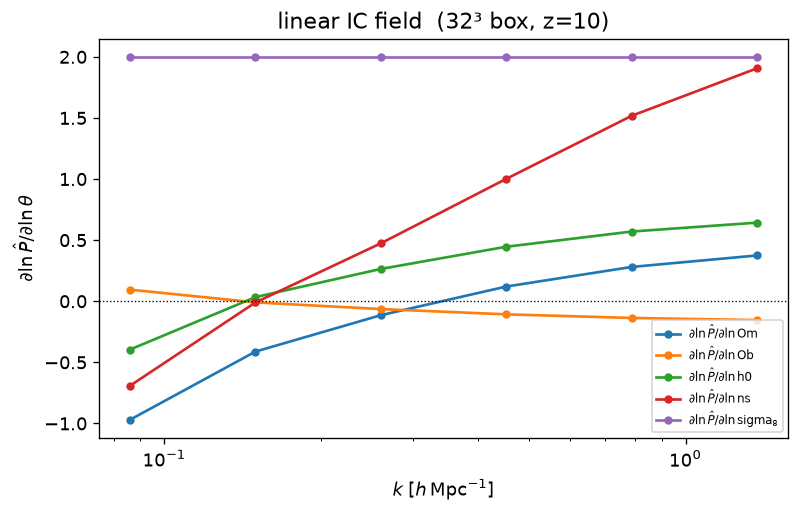

In [9]:
if _JAX:
    J_lin, P0_lin = jac_Phat(field_linear)
    print(f'linear IC field: dP̂/dσ₈ jacfwd vs finite differences — '
          f'max rel err = {fd_check(field_linear, J_lin):.2e}')
    fig, ax = plt.subplots(figsize=(6.8, 4.4))
    dlogP_linear = plot_dlogP(ax, J_lin, P0_lin,
                              f'linear IC field  ({Nd}³ box, z={zd:.0f})')
    plt.tight_layout()
    plt.show()
else:
    print('JAX is not installed — autodiff demo skipped.')


---
<a id="sec4"></a>
## 4. 1LPT / Zel'dovich density field

The Zel'dovich displacement $\Psi^{(1)}$ moves particles from their
Lagrangian positions $\mathbf{q}$ to Eulerian positions
$\mathbf{x} = \mathbf{q} + D_1(z)\,\Psi^{(1)}(\mathbf{q})$; CIC-painting
the displaced particles gives the 1LPT density field.


z = 10.0   D₁(z)/D(0) = 0.11536
Ψx rms = 0.602 Mpc/h  Ψy rms = 0.602 Mpc/h  Ψz rms = 0.602 Mpc/h


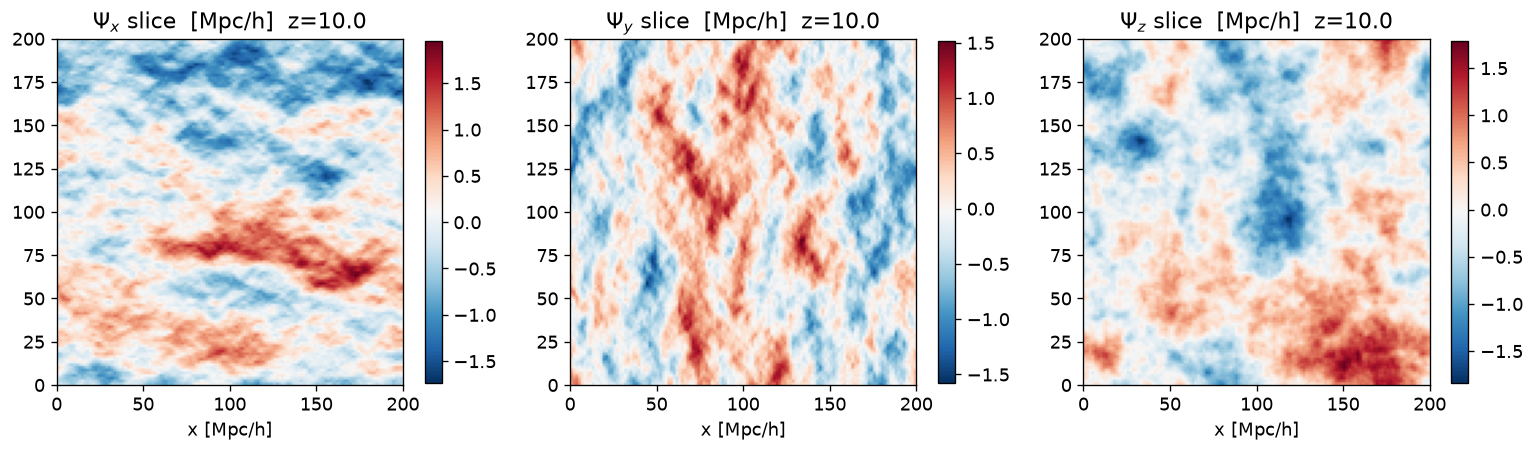

In [10]:
z_target = 10.0

psi_x, psi_y, psi_z = za.get_displacement(z=z_target)
a_t = 1 / (1 + z_target)
D1  = D(a_t, param) / D(1.0, param)

print(f'z = {z_target}   D₁(z)/D(0) = {D1:.5f}')
print(f'Ψx rms = {psi_x.std():.3f} Mpc/h  '
      f'Ψy rms = {psi_y.std():.3f} Mpc/h  '
      f'Ψz rms = {psi_z.std():.3f} Mpc/h')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
sl = param.simulation.Ncell // 2
L  = param.simulation.Lbox
for ax, field, label in zip(axes,
                             [psi_x, psi_y, psi_z],
                             [r'$\Psi_x$', r'$\Psi_y$', r'$\Psi_z$']):
    im = ax.imshow(field[:, :, sl], origin='lower', cmap='RdBu_r',
                   extent=[0, L, 0, L])
    ax.set_title(f'{label} slice  [Mpc/h]  z={z_target}')
    ax.set_xlabel('x [Mpc/h]')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

ZA density:  mean=-1.164e-10  std=0.3388


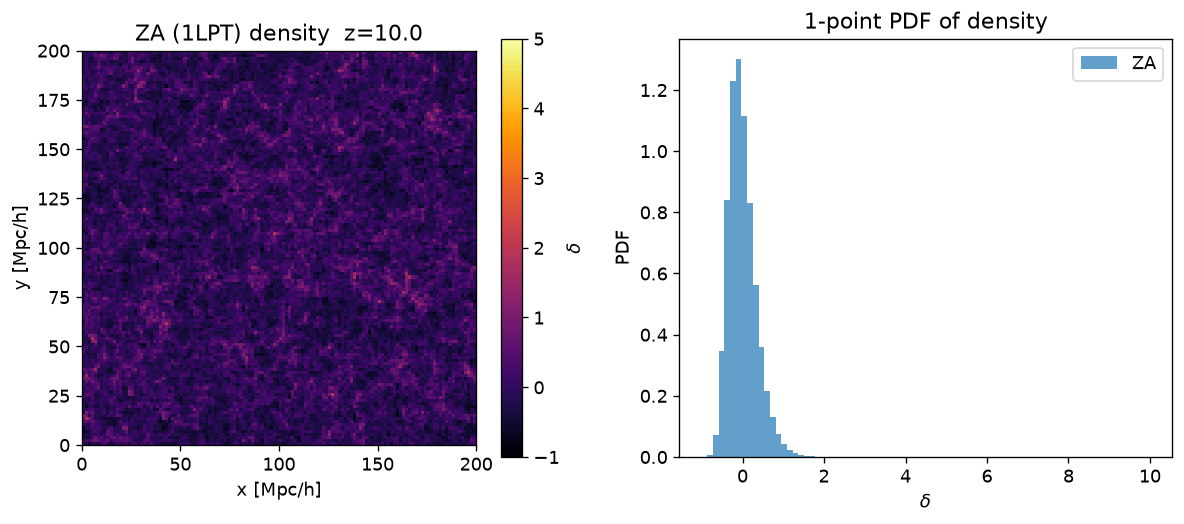

In [11]:
# 1LPT density field
delta_za = za.get_density(z=z_target)
print(f'ZA density:  mean={delta_za.mean():.3e}  std={delta_za.std():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

ax = axes[0]
im = ax.imshow(delta_za[:, :, sl], origin='lower', cmap='inferno',
               extent=[0, L, 0, L], vmin=-1, vmax=5)
ax.set_title(f'ZA (1LPT) density  z={z_target}')
ax.set_xlabel('x [Mpc/h]')
ax.set_ylabel('y [Mpc/h]')
plt.colorbar(im, ax=ax, label=r'$\delta$')

ax = axes[1]
bins = np.linspace(-1, 10, 80)
ax.hist(delta_za.ravel(), bins=bins, density=True, alpha=0.7, label='ZA')
ax.set_xlabel(r'$\delta$')
ax.set_ylabel('PDF')
ax.set_title('1-point PDF of density')
ax.legend()

plt.tight_layout()
plt.show()

### 4.1 Validation against 21cmFAST

**Goal:** compare BEoRN's ZA density field against the field produced by
`py21cmfast` with the same cosmology, box size, and random seed, and show
how to feed a 21cmFAST GRF directly into BEoRN for a structure-by-structure
comparison.

21cmFAST and BEoRN both implement the Zel'dovich approximation but generate
their Gaussian random field (GRF) using different random-number libraries
(GSL in C vs NumPy).  Two comparison modes are therefore available:

| Mode | What it tests | Seeding |
|---|---|---|
| **Statistical** | P(k), PDF agree to < 5 % | Any matching seed (RNG-agnostic) |
| **Pixel-level** | δ(x) field matches at every cell | Inject 21cmFAST GRF via `grf=` parameter |

`py21cmfast.InitialConditions.lowres_density` stores the linear overdensity
field δ at the `HII_DIM` grid, normalised at z = 0.  Feeding its Fourier
transform directly to BEoRN bypasses BEoRN's own RNG and P(k) normalisation:

```python
delta_k_21cm = np.fft.rfftn(IC.lowres_density)  # shape (N, N, N//2+1)
za_21cm = lpt.ZeldovichApproximation(param, verbose=False)
za_21cm.generate_initial_conditions(grf=delta_k_21cm)
delta_beorn = za_21cm.get_density(z=z_target)
```

Both codes then solve the same ZA problem from the same δ(k) starting point,
so the resulting density fields should agree at the few-percent level.


In [12]:
try:
    import py21cmfast as p21c
    _p21cm_available = True
    print(f'py21cmfast {p21c.__version__} found.')
except ImportError:
    _p21cm_available = False
    print('py21cmfast not installed — install with: pip install py21cmfast')
    print('Cells below show the full comparison code; outputs require py21cmfast.')

# ── py21cmfast setup (mirrors the BEoRN param object) ─────────────────────────
if _p21cm_available:
    cosmo = param.cosmology
    N21   = param.simulation.Ncell
    L21   = param.simulation.Lbox / cosmo.h0   # py21cmfast uses Mpc, not Mpc/h

    user_params = p21c.UserParams(
        HII_DIM=N21,
        DIM=N21 * 3,          # high-res internal grid
        BOX_LEN=L21,
        N_THREADS=4,
    )
    cosmo_params = p21c.CosmoParams(
        SIGMA_8=cosmo.sigma_8,
        hlittle=cosmo.h0,
        OMm=cosmo.Om,
        OMb=cosmo.Ob,
        POWER_INDEX=cosmo.ns,
    )

    print('Computing 21cmFAST initial conditions...')
    IC = p21c.initial_conditions(
        user_params=user_params,
        cosmo_params=cosmo_params,
        random_seed=SEED,
        direc='cache',
    )

    # lowres_density: linear δ on the HII_DIM grid (shape N×N×N, units: overdensity)
    delta_21cm_ic = IC.lowres_density
    print(f'IC.lowres_density  shape={delta_21cm_ic.shape}  '
          f'mean={delta_21cm_ic.mean():.3e}  std={delta_21cm_ic.std():.4f}')

    # Perturbed (ZA-displaced) field at z_target
    pf = p21c.perturb_field(
        redshift=z_target, 
        init_boxes=IC,
        direc='cache',
        )
    delta_21cm_z = pf.density
    print(f'perturb_field.density  z={z_target}  '
          f'mean={delta_21cm_z.mean():.3e}  std={delta_21cm_z.std():.4f}')

    # ── GRF injection: pass 21cmFAST δ(k) to BEoRN ─────────────────────────────
    # Shape (N, N, N//2+1) → skips BEoRN's own P(k) normalisation, uses 21cmFAST's
    delta_k_21cm = np.fft.rfftn(delta_21cm_ic)

    za_21cm = lpt.ZeldovichApproximation(param, verbose=False)
    za_21cm.generate_initial_conditions(grf=delta_k_21cm)
    delta_beorn_from_21cm = za_21cm.get_density(z=z_target)

    print(f'\nBEoRN (from 21cmFAST GRF)  '
          f'mean={delta_beorn_from_21cm.mean():.3e}  '
          f'std={delta_beorn_from_21cm.std():.4f}')

py21cmfast not installed — install with: pip install py21cmfast
Cells below show the full comparison code; outputs require py21cmfast.


In [13]:
if _p21cm_available:
    # ── Statistical comparison: P(k) ──────────────────────────────────────────
    k_21ic,  Pk_21ic  = ps1d(delta_21cm_ic,          L)
    k_21z,   Pk_21z   = ps1d(delta_21cm_z,           L)
    k_beo21, Pk_beo21 = ps1d(delta_beorn_from_21cm,  L)
    Pk_th_z  = eh_nw.P(k_21z, z=z_target)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    ax = axes[0]
    ax.loglog(k_21ic,  Pk_21ic,   'C3v',  ms=4, label=f'21cmFAST IC (z=0)')
    ax.loglog(k_21z,   Pk_21z,    'C0o',  ms=4, label=f'21cmFAST ZA (z={z_target:.0f})')
    ax.loglog(k_beo21, Pk_beo21,  'C1s',  ms=4, label=f'BEoRN (21cmFAST GRF, z={z_target:.0f})')
    ax.loglog(k_21z,   Pk_th_z,   'k-',   lw=2, label=f'E&H (z={z_target:.0f})')
    ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
    ax.set_ylabel(r'$P(k)\;[(\mathrm{Mpc}/h)^3]$')
    ax.set_title('P(k) — 21cmFAST vs BEoRN')
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.semilogx(k_21z,   Pk_21z   / Pk_th_z, 'C0o', ms=4, label=f'21cmFAST ZA (z={z_target:.0f})')
    ax.semilogx(k_beo21, Pk_beo21 / np.interp(k_beo21, k_21z, Pk_th_z),
                'C1s', ms=4, label=f'BEoRN (21cmFAST GRF, z={z_target:.0f})')
    ax.axhline(1, ls='--', color='k', lw=1)
    ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
    ax.set_ylabel(r'$P(k) / P_\mathrm{theory}$')
    ax.set_title('Ratio to E&H theory')
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print('(py21cmfast not installed — skipping P(k) comparison)')

(py21cmfast not installed — skipping P(k) comparison)


In [14]:
if _p21cm_available:
    # ── Pixel-level comparison: BEoRN (21cmFAST GRF) vs 21cmFAST ZA ──────────
    r_21 = np.corrcoef(delta_21cm_z.ravel(), delta_beorn_from_21cm.ravel())[0, 1]
    print(f'Pixel correlation (21cmFAST ZA vs BEoRN from 21cmFAST GRF): r = {r_21:.4f}')

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    sl = N // 2
    vmin, vmax = -1, 4

    for ax, field, title in zip(
        axes,
        [delta_21cm_z[:, :, sl], delta_beorn_from_21cm[:, :, sl],
         (delta_beorn_from_21cm - delta_21cm_z)[:, :, sl]],
        [f'21cmFAST ZA  z={z_target}',
         f'BEoRN ZA (from 21cmFAST GRF)',
         'Residual (BEoRN − 21cmFAST)'],
    ):
        vm = (vmin, vmax) if 'Residual' not in title else (-1, 1)
        cm = 'inferno' if 'Residual' not in title else 'RdBu_r'
        im = ax.imshow(field, origin='lower', cmap=cm,
                       extent=[0, L, 0, L], vmin=vm[0], vmax=vm[1])
        ax.set_title(title)
        ax.set_xlabel('x [Mpc/h]')
        plt.colorbar(im, ax=ax, label=r'$\delta$', shrink=0.8)

    axes[0].set_ylabel('y [Mpc/h]')
    plt.tight_layout()
    plt.show()

    # Scatter plot: pixel-by-pixel
    stride = max(1, N**3 // 4000)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(delta_21cm_z.ravel()[::stride],
               delta_beorn_from_21cm.ravel()[::stride],
               s=2, alpha=0.3)
    lim = max(abs(delta_21cm_z).max(), abs(delta_beorn_from_21cm).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1.5, label='1:1')
    ax.set_xlabel(r'21cmFAST $\delta$')
    ax.set_ylabel(r'BEoRN $\delta$ (from 21cmFAST GRF)')
    ax.set_title(f'Pixel-level comparison  $r = {r_21:.4f}$')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('(py21cmfast not installed — skipping pixel comparison)')
    print()
    print('Expected outcomes once py21cmfast is available:')
    print('  • P(k) agreement < 5 % on large scales (k < 1 h/Mpc)')
    print('  • Pixel correlation r > 0.95 between 21cmFAST ZA and BEoRN (from 21cmFAST GRF)')
    print('  • Residual δ_BEoRN − δ_21cmFAST < few % — differences come from:')
    print('    – CIC mass-assignment window (small)')
    print('    – Growth-factor normalisation conventions (< 1 %)')

(py21cmfast not installed — skipping pixel comparison)

Expected outcomes once py21cmfast is available:
  • P(k) agreement < 5 % on large scales (k < 1 h/Mpc)
  • Pixel correlation r > 0.95 between 21cmFAST ZA and BEoRN (from 21cmFAST GRF)
  • Residual δ_BEoRN − δ_21cmFAST < few % — differences come from:
    – CIC mass-assignment window (small)
    – Growth-factor normalisation conventions (< 1 %)


### 4.2 GPU acceleration test

The LPT solvers accept a `backend=` argument; with `TorchBackend('mps')` /
`TorchBackend('cuda')` the FFTs and k-space algebra run on the GPU.  Same
δ(k) in, same fields out (float32 on Apple MPS).


In [15]:
if _TORCH_AVAILABLE and torch_gpu is not None:
    from beorn.lpt import TorchBackend
    za_gpu = lpt.ZeldovichApproximation(param, verbose=False,
                                        backend=TorchBackend(torch_gpu))
    za_gpu.generate_initial_conditions(grf=za.delta_k)     # same realisation
    dza_gpu = za_gpu.get_density(z_target)
    print(f'ZA density torch-{torch_gpu} vs numpy: max|Δδ|/std = '
          f'{np.max(np.abs(dza_gpu - delta_za)) / delta_za.std():.2e}'
          + ('  (float32 on MPS)' if torch_gpu == 'mps' else ''))
    t_cpu = bench(lambda: za.get_displacement(z_target), n=3)
    t_gpu = bench(lambda: za_gpu.get_displacement(z_target), n=3)
    print(f'get_displacement {N}³:  numpy {t_cpu*1e3:6.0f} ms   '
          f'torch-{torch_gpu} {t_gpu*1e3:6.0f} ms   ({t_cpu/t_gpu:.1f}×)')
else:
    print('GPUs not available — ZA GPU test skipped.')


ZA density torch-cuda vs numpy: max|Δδ|/std = 0.00e+00
get_displacement 128³:  numpy     33 ms   torch-cuda      1 ms   (39.1×)


### 4.3 Autodiff test: dP̂(k)/dθ of the ZA density field

Differentiable pipeline: θ → δ(k) → ZA displacements → differentiable CIC
painting (`beorn.particle_mapping.paint_mesh_jax`) → measured $\hat P(k)$ →
jacobian.  Dashed lines: linear-field gradients from section 3.1.


ZA CIC field: dP̂/dσ₈ jacfwd vs FD — max rel err = 6.31e-09


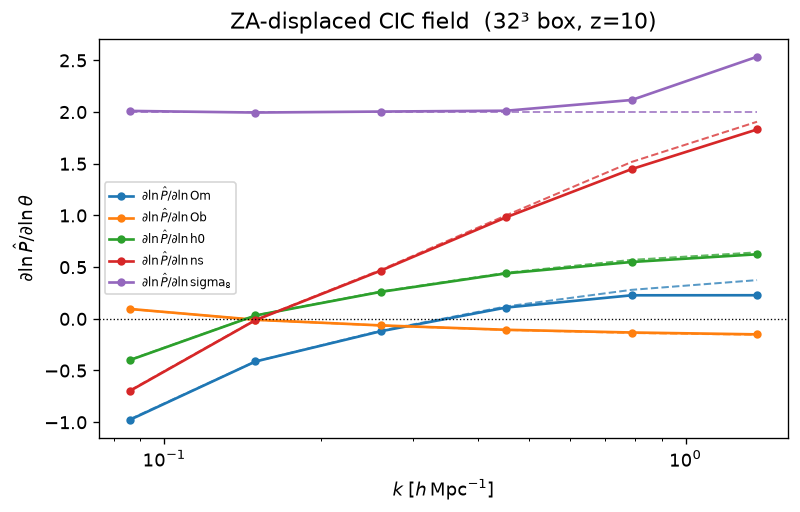

Dashed: linear-field gradients.  ZA tracks linear theory on large scales; departures at high k mark displacement + CIC nonlinearity.


In [16]:
if _JAX:
    from beorn.particle_mapping import paint_mesh_jax

    def field_za_diff(theta):
        dkd = delta_k_of(theta)
        px = jnp.fft.irfftn(1j * kxj * ik2j * dkd, s=(Nd,)*3)
        py = jnp.fft.irfftn(1j * kyj * ik2j * dkd, s=(Nd,)*3)
        pz = jnp.fft.irfftn(1j * kzj * ik2j * dkd, s=(Nd,)*3)
        pos = jnp.stack([((qxd + px) % Ld).ravel(),
                         ((qyd + py) % Ld).ravel(),
                         ((qzd + pz) % Ld).ravel()], axis=-1)
        mesh = paint_mesh_jax(pos, Nd, Ld)        # differentiable CIC
        return mesh / mesh.mean() - 1.0

    J_za, P0_za = jac_Phat(field_za_diff)
    print(f'ZA CIC field: dP̂/dσ₈ jacfwd vs FD — max rel err = '
          f'{fd_check(field_za_diff, J_za):.2e}')
    fig, ax = plt.subplots(figsize=(6.8, 4.4))
    plot_dlogP(ax, J_za, P0_za,
               f'ZA-displaced CIC field  ({Nd}³ box, z={zd:.0f})',
               ref=dlogP_linear)
    plt.tight_layout()
    plt.show()
    print('Dashed: linear-field gradients.  ZA tracks linear theory on large '
          'scales; departures at high k mark displacement + CIC nonlinearity.')
else:
    print('JAX is not installed — ZA autodiff demo skipped.')


---
<a id="sec5"></a>
## 5. 2LPT density field

2LPT adds a second-order correction driven by
$$\Delta^{(2)} = \sum_{i<j}\left[\varphi^{(1)}_{,ii}\,\varphi^{(1)}_{,jj} - \left(\varphi^{(1)}_{,ij}\right)^2\right]$$
with growth factor $D_2(z) \approx -\tfrac{3}{7}D_1^2(z)$.
(The ZA field was already validated against 21cmFAST in section 4.1; the
2LPT-specific tests below are convergence, GPU execution and autodiff.)


In [17]:
lpt2 = lpt.SecondOrderLPT(param, seed=SEED)   # same seed → same δ(k)

psi2_x, psi2_y, psi2_z = lpt2.get_displacement(z=z_target)
delta_2lpt = lpt2.get_density(z=z_target)

D2 = -3/7 * D1**2
print(f'D₂/D₁ = {D2/D1:.5f}')
print(f'2LPT Ψx rms = {psi2_x.std():.3f} Mpc/h   '
      f'ZA  Ψx rms = {psi_x.std():.3f} Mpc/h')

[BEoRN LPT] backend → NumpyBackend  (scipy.fft, 288 workers)


D₂/D₁ = -0.04944
2LPT Ψx rms = 0.602 Mpc/h   ZA  Ψx rms = 0.602 Mpc/h


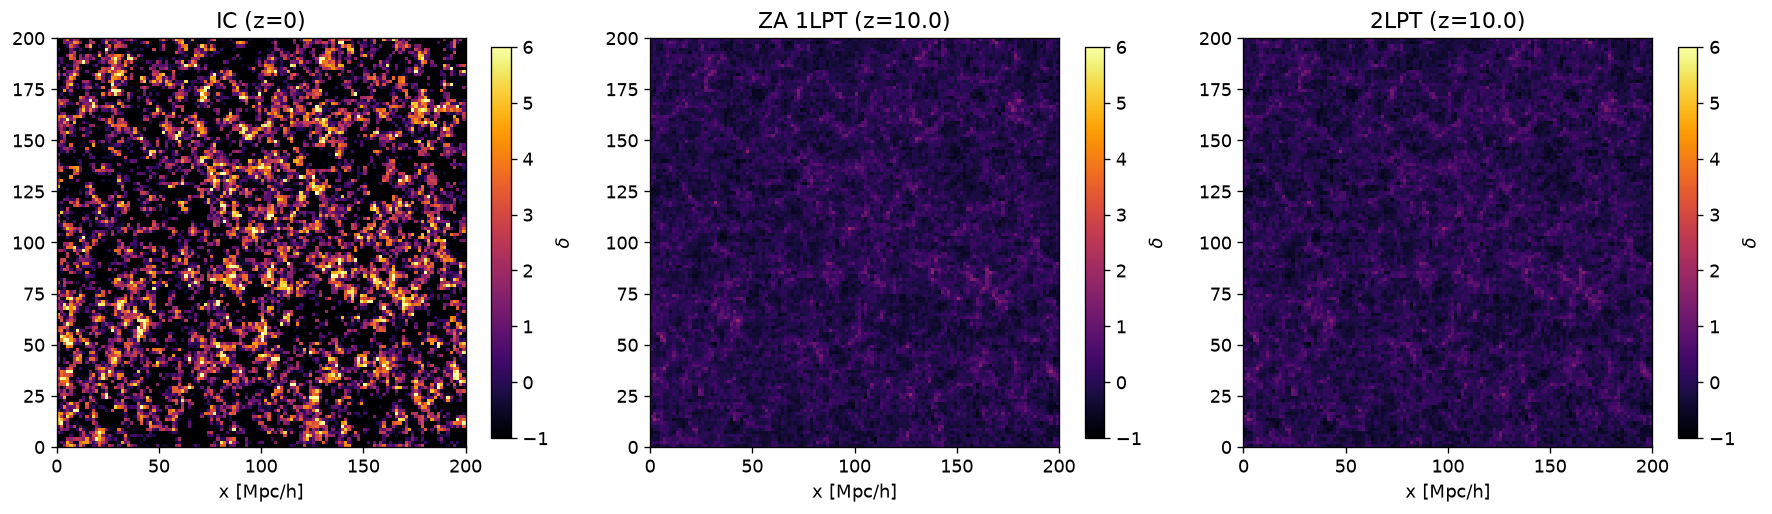

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

vmin, vmax = -1, 6
for ax, field, title in zip(axes,
    [delta_ic[:,:,sl], delta_za[:,:,sl], delta_2lpt[:,:,sl]],
    ['IC (z=0)', f'ZA 1LPT (z={z_target})', f'2LPT (z={z_target})']):
    im = ax.imshow(field, origin='lower', cmap='inferno',
                   extent=[0, L, 0, L], vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel('x [Mpc/h]')
    plt.colorbar(im, ax=ax, label=r'$\delta$', shrink=0.8)

plt.tight_layout()
plt.show()

Shot noise floor: P_shot = (L/N)³ = 3.815 (Mpc/h)³
Linear P(k=1 h/Mpc, z=10.0) = 0.920 (Mpc/h)³


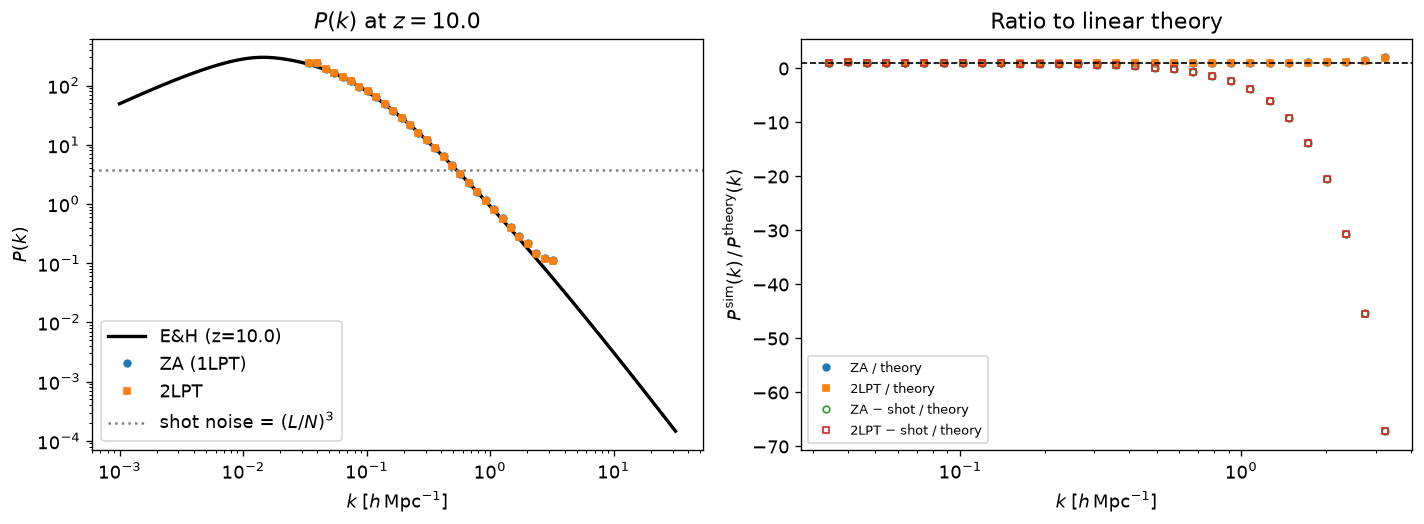

In [19]:
# Power spectra: ZA vs 2LPT vs theory
k_za,   Pk_za   = ps1d(delta_za,   L)
k_2lpt, Pk_2lpt = ps1d(delta_2lpt, L)
Pk_theory = eh_nw.P(k, z=z_target)

# Shot noise from discrete CIC particles: P_shot = (L/N)³ (Mpc/h)³
P_shot = (L / N)**3
print(f'Shot noise floor: P_shot = (L/N)³ = {P_shot:.3f} (Mpc/h)³')
print(f'Linear P(k=1 h/Mpc, z={z_target}) = {eh_nw.P(np.array([1.0]), z=z_target)[0]:.3f} (Mpc/h)³')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.loglog(k,       Pk_theory,           'k-',  lw=2,  label=f'E&H (z={z_target})')
ax.loglog(k_za,    Pk_za,               'o',   ms=4,  label='ZA (1LPT)')
ax.loglog(k_2lpt,  Pk_2lpt,             's',   ms=4,  label='2LPT')
ax.axhline(P_shot, ls=':', color='grey', lw=1.5, label=f'shot noise = $(L/N)^3$')
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k)$')
ax.set_title(f'$P(k)$ at $z={z_target}$')
ax.legend()

ax = axes[1]
ax.semilogx(k_za,   Pk_za   / np.interp(k_za,   k, Pk_theory), 'o', ms=4, label='ZA / theory')
ax.semilogx(k_2lpt, Pk_2lpt / np.interp(k_2lpt, k, Pk_theory), 's', ms=4, label='2LPT / theory')
ax.semilogx(k_za,   (Pk_za   - P_shot) / np.interp(k_za,   k, Pk_theory),
            'o', ms=4, mfc='none', label='ZA − shot / theory')
ax.semilogx(k_2lpt, (Pk_2lpt - P_shot) / np.interp(k_2lpt, k, Pk_theory),
            's', ms=4, mfc='none', label='2LPT − shot / theory')
ax.axhline(1, ls='--', color='k', lw=1)
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P^\mathrm{sim}(k)\,/\,P^\mathrm{theory}(k)$')
ax.set_title('Ratio to linear theory')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

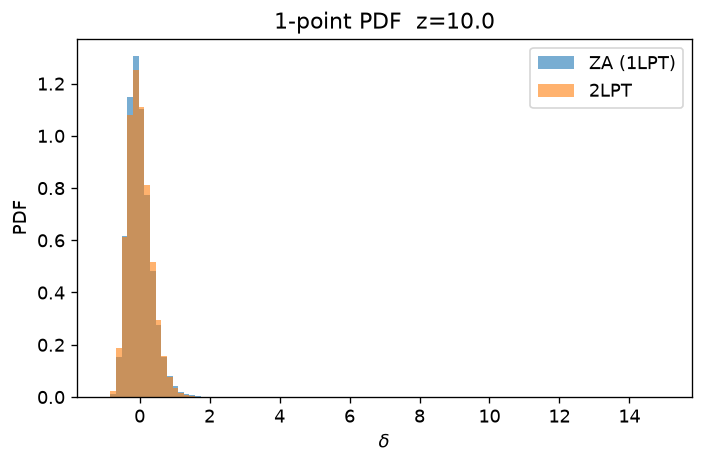

In [20]:
# 1-point PDF comparison
bins = np.linspace(-1, 15, 100)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(delta_za.ravel(),   bins=bins, density=True, alpha=0.6, label='ZA (1LPT)')
ax.hist(delta_2lpt.ravel(), bins=bins, density=True, alpha=0.6, label='2LPT')
ax.set_xlabel(r'$\delta$')
ax.set_ylabel('PDF')
ax.set_title(f'1-point PDF  z={z_target}')
ax.legend()
plt.tight_layout()
plt.show()

### 5.1 LPT order convergence

The LPT expansion converges when $D_1(z)\,|\nabla\Psi^{(1)}| \ll 1$.
We check convergence by comparing displacement rms across orders at several
redshifts, and confirm through the growth-factor ratios that the
higher-order corrections shrink at high $z$.  At low redshift the hierarchy
diverges — this is expected and motivates using 2LPT at high $z$.


[BEoRN LPT] backend → NumpyBackend  (scipy.fft, 288 workers)
[BEoRN LPT] backend → NumpyBackend  (scipy.fft, 288 workers)
[BEoRN LPT] backend → NumpyBackend  (scipy.fft, 288 workers)


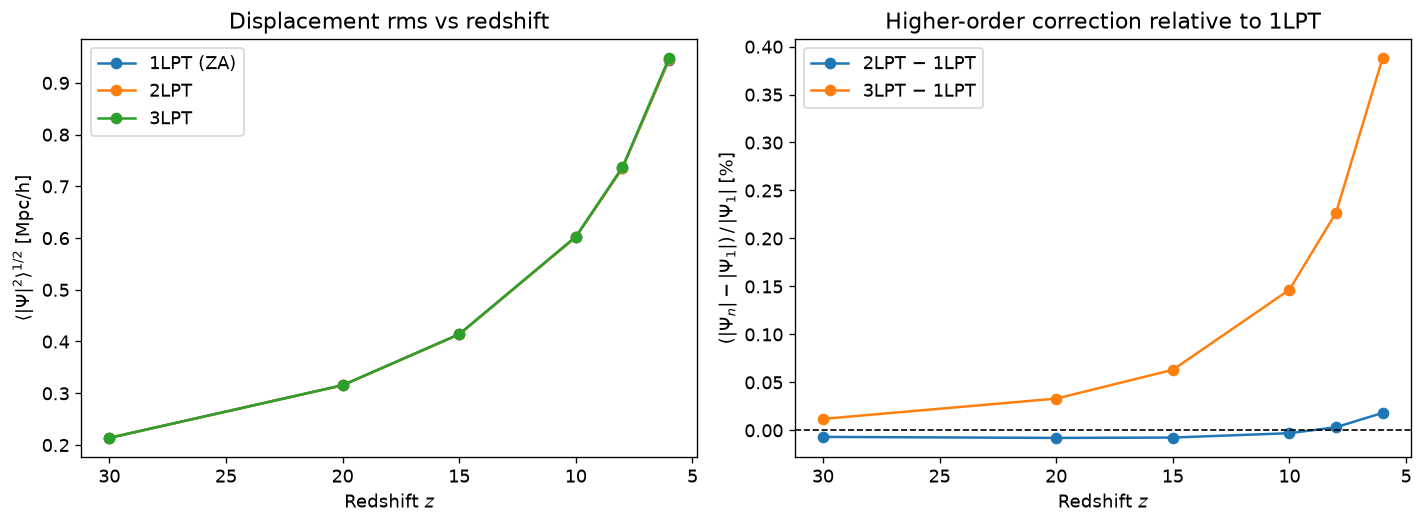

In [21]:
redshifts = [30, 20, 15, 10, 8, 6]
solvers = {
    '1LPT (ZA)': lpt.ZeldovichApproximation(param, seed=SEED),
    '2LPT':      lpt.SecondOrderLPT(param, seed=SEED),
    '3LPT':      lpt.ThirdOrderLPT(param, seed=SEED),
}

results = {name: [] for name in solvers}
for z in redshifts:
    for name, solver in solvers.items():
        psi = solver.get_displacement(z)
        rms = np.sqrt(np.mean([c**2 for c in psi]))
        results[name].append(rms)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
for name, vals in results.items():
    ax.plot(redshifts, vals, 'o-', label=name)
ax.set_xlabel('Redshift $z$')
ax.set_ylabel(r'$\langle|\Psi|^2\rangle^{1/2}$ [Mpc/h]')
ax.set_title('Displacement rms vs redshift')
ax.legend()
ax.invert_xaxis()

ax = axes[1]
rms_1lpt = np.array(results['1LPT (ZA)'])
for name, vals in results.items():
    if name == '1LPT (ZA)':
        continue
    ratio = (np.array(vals) - rms_1lpt) / rms_1lpt * 100
    ax.plot(redshifts, ratio, 'o-', label=f'{name} − 1LPT')
ax.axhline(0, ls='--', color='k', lw=1)
ax.set_xlabel('Redshift $z$')
ax.set_ylabel(r'$(|\Psi_n| - |\Psi_1|)\,/\,|\Psi_1|\;[\%]$')
ax.set_title('Higher-order correction relative to 1LPT')
ax.legend()
ax.invert_xaxis()

plt.tight_layout()
plt.show()

In [22]:
# Growth factor ratios: confirm that higher-order corrections shrink at high z
print('z     D₁        D₂/D₁     D₃ₐ/D₁²')
print('-'*45)
for z in redshifts:
    a  = 1/(1+z)
    D1 = D(a, param) / D(1.0, param)
    D2 = -3/7 * D1**2
    D3a = 1/3 * D1**3
    print(f'{z:4d}  {D1:.5f}   {D2/D1:+.5f}   {D3a/D1**2:+.5f}')

z     D₁        D₂/D₁     D₃ₐ/D₁²
---------------------------------------------
  30  0.04094   -0.01755   +0.01365
  20  0.06044   -0.02590   +0.02015
  15  0.07933   -0.03400   +0.02644
  10  0.11536   -0.04944   +0.03845
   8  0.14097   -0.06041   +0.04699
   6  0.18113   -0.07763   +0.06038


### 5.2 GPU acceleration test

The z-independent k-space sources (δ(k), Δ⁽²⁾(k), Δ⁽³ᵃ⁾(k), Δ⁽³ᵇ⁾(k)) are
computed once per realisation and cached on the backend device, so *any*
redshift's displacement + velocity costs just 3 inverse FFTs — 2LPT/3LPT
redshift scans cost the same as ZA.  With a GPU backend the whole scan runs
on the device.


In [23]:
# ── Source caching: any-z displacement/velocity costs 3 inverse FFTs ─────────
# The z-independent k-space sources (δ(k), Δ⁽²⁾(k), Δ⁽³ᵃ⁾(k), Δ⁽³ᵇ⁾(k)) are
# computed once per realisation and cached on the backend device; the scan
# above reuses them, so 2LPT/3LPT redshift scans cost the same as ZA.
def zscan(s):
    for z_i in redshifts:
        s.get_displacement(z_i)
        s.get_velocity(z_i)

for nm, s in solvers.items():
    zscan(s)                       # warm-up: builds the source cache
    t = bench(lambda: zscan(s), n=3)
    print(f'{nm:10s} {len(redshifts)}-z displacement+velocity scan: {t*1e3:7.0f} ms')

if _TORCH_AVAILABLE and torch_gpu is not None:
    from beorn.lpt import TorchBackend
    s_gpu = lpt.SecondOrderLPT(param, seed=SEED, verbose=False,
                               backend=TorchBackend(torch_gpu))
    s_gpu.generate_initial_conditions(grf=solvers['2LPT'].delta_k)  # same ICs
    px_g, _, _ = s_gpu.get_displacement(z_target)
    px_c, _, _ = solvers['2LPT'].get_displacement(z_target)
    print(f'\n2LPT torch-{torch_gpu} vs numpy: max|Δψ|/std = '
          f'{np.max(np.abs(px_g - px_c))/px_c.std():.2e}'
          + ('  (float32 on MPS)' if torch_gpu == 'mps' else ''))
    sync = torch.mps.synchronize if torch_gpu == 'mps' else torch.cuda.synchronize
    def zscan_gpu():
        zscan(s_gpu); sync()
    t_g = bench(zscan_gpu, n=3)
    print(f'2LPT torch-{torch_gpu} {len(redshifts)}-z scan: {t_g*1e3:7.0f} ms')
else:
    print('\nGPUs not available — GPU LPT benchmark skipped.')

1LPT (ZA)  6-z displacement+velocity scan:     120 ms
2LPT       6-z displacement+velocity scan:     144 ms
3LPT       6-z displacement+velocity scan:     178 ms

2LPT torch-cuda vs numpy: max|Δψ|/std = 2.58e-15
2LPT torch-cuda 6-z scan:      12 ms


### 5.3 Autodiff test: dP̂(k)/dθ of the 2LPT density field

The 2LPT source $\Delta^{(2)}$ is built from the six second derivatives of
the 1LPT potential — all FFTs and element-wise products, so the whole 2LPT
pipeline is differentiable end-to-end.  The inline jax pipeline below mirrors
`SecondOrderLPT._compute_sources_k` exactly (with
$D_2 = -\tfrac{3}{7}D_1^2$) and is checked against the numpy solver at the
fiducial cosmology before taking gradients.  Dashed lines: linear-field
gradients.


inline jax 2LPT vs SecondOrderLPT solver: pixel correlation r = 0.950280   (float32 CIC + growth-integral differences)
2LPT CIC field: dP̂/dσ₈ jacfwd vs FD — max rel err = 8.65e-05


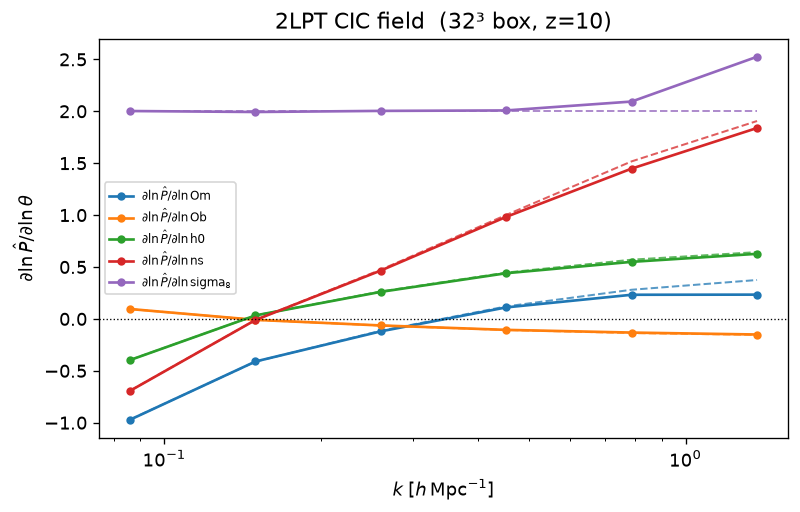

In [24]:
if _JAX:
    def field_2lpt_diff(theta):
        dkd = delta_k_of(theta)                    # D₁(z) already applied

        def phi_ij(ki, kj):                        # φ₁,ᵢⱼ = ℱ⁻¹[−kᵢkⱼ/k² δ(k)]
            return jnp.fft.irfftn(-ki * kj * ik2j * dkd, s=(Nd,)*3)

        pxx, pyy, pzz = phi_ij(kxj, kxj), phi_ij(kyj, kyj), phi_ij(kzj, kzj)
        pxy, pxz, pyz = phi_ij(kxj, kyj), phi_ij(kxj, kzj), phi_ij(kyj, kzj)
        src2 = (pxx*pyy - pxy**2 + pxx*pzz - pxz**2 + pyy*pzz - pyz**2)
        # δ(k) carries D₁ → src2 carries D₁²; D₂ = −3/7 D₁² → coefficient −3/7
        ck = dkd - 3.0/7.0 * jnp.fft.rfftn(src2)
        px = jnp.fft.irfftn(1j * kxj * ik2j * ck, s=(Nd,)*3)
        py = jnp.fft.irfftn(1j * kyj * ik2j * ck, s=(Nd,)*3)
        pz = jnp.fft.irfftn(1j * kzj * ik2j * ck, s=(Nd,)*3)
        pos = jnp.stack([((qxd + px) % Ld).ravel(),
                         ((qyd + py) % Ld).ravel(),
                         ((qzd + pz) % Ld).ravel()], axis=-1)
        mesh = paint_mesh_jax(pos, Nd, Ld)
        return mesh / mesh.mean() - 1.0

    # parity vs the numpy SecondOrderLPT solver at the fiducial cosmology
    param_d = Parameters()
    param_d.simulation.Ncell, param_d.simulation.Lbox = Nd, Ld
    param_d.simulation.use_hunits = True  # Ld above is in Mpc/h, matching the manual JAX pipeline's box-size assumption
    dk0_fid = np.asarray(delta_k_of(theta_fid)
                         / growth_factor(ad, cosmo.Om, backend='jax'))
    s2_ref = lpt.SecondOrderLPT(param_d, verbose=False)
    s2_ref.generate_initial_conditions(grf=dk0_fid)
    d_ref = s2_ref.get_density(zd)
    d_jax = np.asarray(field_2lpt_diff(theta_fid))
    r2 = np.corrcoef(d_ref.ravel(), d_jax.ravel())[0, 1]
    print(f'inline jax 2LPT vs SecondOrderLPT solver: pixel correlation '
          f'r = {r2:.6f}   (float32 CIC + growth-integral differences)')

    J_2l, P0_2l = jac_Phat(field_2lpt_diff)
    print(f'2LPT CIC field: dP̂/dσ₈ jacfwd vs FD — max rel err = '
          f'{fd_check(field_2lpt_diff, J_2l):.2e}')
    fig, ax = plt.subplots(figsize=(6.8, 4.4))
    plot_dlogP(ax, J_2l, P0_2l,
               f'2LPT CIC field  ({Nd}³ box, z={zd:.0f})', ref=dlogP_linear)
    plt.tight_layout()
    plt.show()
else:
    print('JAX is not installed — 2LPT autodiff demo skipped.')


---
<a id="sec6"></a>
## 6. Velocity fields

The LPT peculiar velocity is:

$$\mathbf{v}(\mathbf{q},z) = a(z)\,\frac{H(z)}{h}\left[f_1(z)\,D_1(z)\,\boldsymbol{\Psi}^{(1)} + f_2(z)\,D_2(z)\,\boldsymbol{\Psi}^{(2)} + \cdots\right]$$

where $f_n = \mathrm{d}\ln D_n/\mathrm{d}\ln a$ is the growth rate for
order $n$, $H(z)/h$ is in km/s/(Mpc/h), and $\boldsymbol{\Psi}$ is in
Mpc/h, so $\mathbf{v}$ is in km/s.
EdS approximation: $f_n \approx n\,f_1$ for $n \leq 3$ (accurate to < 1 %
at $z > 2$).

### Validation checks
1. **Growth rate**: $f_1(z) \approx \Omega_m(z)^{0.55}$ (Linder 2005 approximation)
2. **Velocity maps vs density maps**: infall onto the overdense structures
3. **Velocity rms vs theory**: $\sigma_v = (a H/h)\,f_1\,\sigma_\Psi$
4. **Velocity power spectrum**: $P_{v_x}(k) = (aHf_1/h)^2\,P_\delta(k)/(3k^2)$ per component
5. **Continuity equation**: $\boldsymbol{\nabla}\cdot\mathbf{v} = -a\,\frac{H}{h}\,f_1\,\delta_\mathrm{lin}$ (exact at 1LPT)
6. **ZA vs 2LPT velocity comparison**


In [25]:
from beorn.cosmo import hubble

# ── Cosmological factors at z_target ─────────────────────────────────────────
a_z     = 1.0 / (1.0 + z_target)
Hz      = hubble(z_target, param)          # km/s/Mpc (physical)
Hz_nat  = Hz / param.cosmology.h0          # km/s/(Mpc/h)  — consistent with Lbox
f1_num  = za._f1(z_target)                 # numerical d ln D₁ / d ln a
Om_z    = param.cosmology.Om * (1+z_target)**3 / (param.cosmology.Om*(1+z_target)**3 + 1-param.cosmology.Om)
f1_linder = Om_z**0.55                     # Linder (2005) approximation

print(f'z = {z_target}')
print(f'  a              = {a_z:.5f}')
print(f'  H(z)           = {Hz:.2f} km/s/Mpc')
print(f'  H(z)/h         = {Hz_nat:.2f} km/s/(Mpc/h)')
print(f'  f₁ (numerical) = {f1_num:.5f}')
print(f'  f₁ (Linder)    = {f1_linder:.5f}   Ωm(z)^0.55')
print(f'  aH/h           = {a_z * Hz_nat:.3f} km/s/(Mpc/h)')
print(f'  aHf₁/h         = {a_z * Hz_nat * f1_num:.3f} km/s/(Mpc/h)')

# ── Compute velocity fields ────────────────────────────────────────────────────
vza_x,  vza_y,  vza_z  = za.get_velocity(z=z_target)
v2_x,   v2_y,   v2_z   = lpt2.get_velocity(z=z_target)

sigma_psi = psi_x.std()   # ZA displacement rms, already computed above
sigma_v_expected = a_z * Hz_nat * f1_num * sigma_psi  # D₁ already in psi_x

print(f'\nVelocity rms (ZA, x-component):')
print(f'  measured           = {vza_x.std():.3f} km/s')
print(f'  expected (aHf₁Ψ)   = {sigma_v_expected:.3f} km/s')

z = 10.0
  a              = 0.09091
  H(z)           = 1379.16 km/s/Mpc
  H(z)/h         = 2049.27 km/s/(Mpc/h)
  f₁ (numerical) = 0.99914
  f₁ (Linder)    = 0.99910   Ωm(z)^0.55
  aH/h           = 186.297 km/s/(Mpc/h)
  aHf₁/h         = 186.138 km/s/(Mpc/h)



Velocity rms (ZA, x-component):
  measured           = 112.042 km/s
  expected (aHf₁Ψ)   = 112.042 km/s


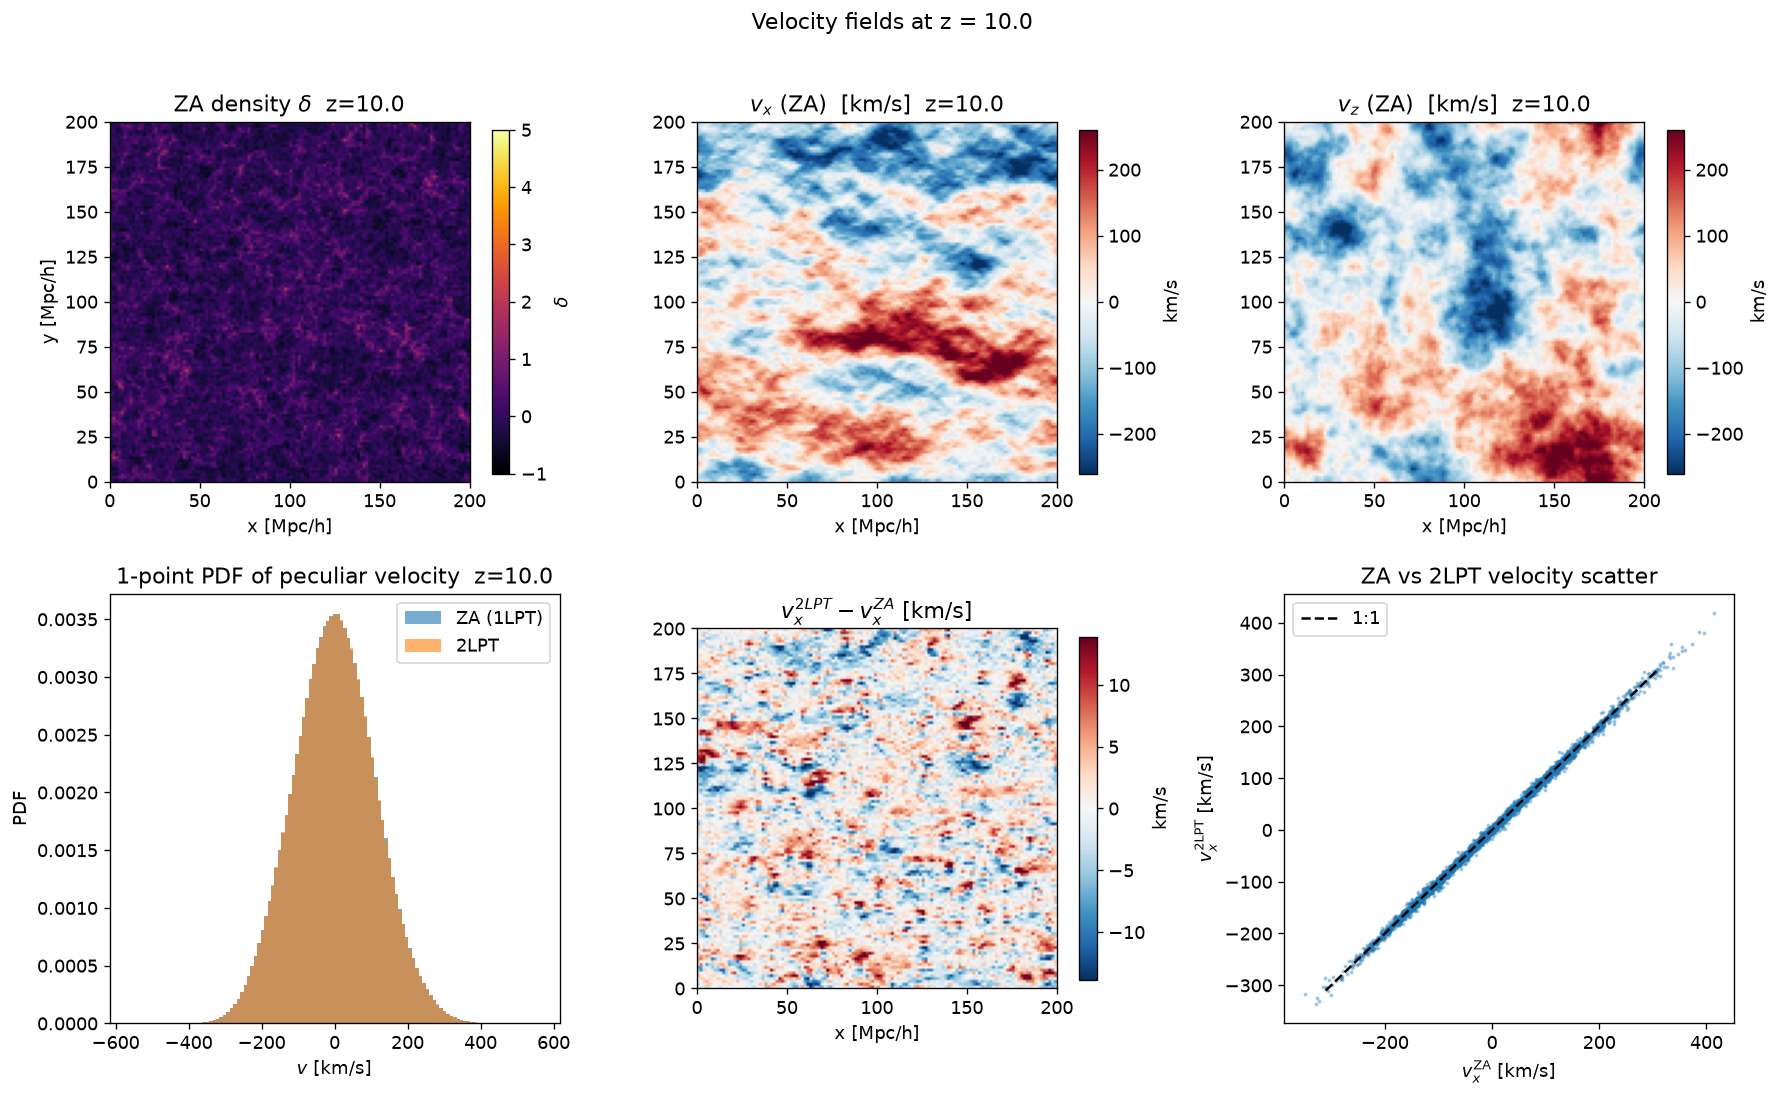

ZA  velocity rms (per component): 112.04 km/s
2LPT velocity rms (per component): 112.11 km/s
Correction |v2 − vZA| rms: 5.045 km/s  (4.5 %)


In [26]:
# ── Velocity slices and PDFs ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Top row: density map next to the velocity maps — coherent flows converge
# onto the overdense structures seen in δ.
vlim = np.percentile(np.abs(vza_x), 98)
im = axes[0][0].imshow(delta_za[:, :, sl], origin='lower', cmap='inferno',
                       extent=[0, L, 0, L], vmin=-1, vmax=5)
axes[0][0].set_title(f'ZA density $\\delta$  z={z_target}')
axes[0][0].set_xlabel('x [Mpc/h]')
axes[0][0].set_ylabel('y [Mpc/h]')
plt.colorbar(im, ax=axes[0][0], label=r'$\delta$', shrink=0.8)
for ax, field, title in zip(
    axes[0][1:],
    [vza_x[:, :, sl], vza_z[:, :, sl]],
    [r'$v_x$ (ZA)', r'$v_z$ (ZA)'],
):
    im = ax.imshow(field, origin='lower', cmap='RdBu_r',
                   extent=[0, L, 0, L], vmin=-vlim, vmax=vlim)
    ax.set_title(f'{title}  [km/s]  z={z_target}')
    ax.set_xlabel('x [Mpc/h]')
    plt.colorbar(im, ax=ax, label='km/s', shrink=0.8)

# ZA vs 2LPT velocity PDF (all three components combined)
vza_all = np.concatenate([vza_x.ravel(), vza_y.ravel(), vza_z.ravel()])
v2_all  = np.concatenate([v2_x.ravel(),  v2_y.ravel(),  v2_z.ravel()])
bins_v  = np.linspace(-5 * vza_all.std(), 5 * vza_all.std(), 120)

axes[1][0].hist(vza_all, bins=bins_v, density=True, alpha=0.6, label='ZA (1LPT)')
axes[1][0].hist(v2_all,  bins=bins_v, density=True, alpha=0.6, label='2LPT')
axes[1][0].set_xlabel('$v$ [km/s]')
axes[1][0].set_ylabel('PDF')
axes[1][0].set_title(f'1-point PDF of peculiar velocity  z={z_target}')
axes[1][0].legend()

# ZA vs 2LPT — per-component residual slice
diff_slice = (v2_x - vza_x)[:, :, sl]
im = axes[1][1].imshow(diff_slice, origin='lower', cmap='RdBu_r',
                        extent=[0, L, 0, L],
                        vmin=-np.percentile(np.abs(diff_slice), 99),
                        vmax= np.percentile(np.abs(diff_slice), 99))
axes[1][1].set_title(r'$v_x^{2LPT} - v_x^{ZA}$ [km/s]')
axes[1][1].set_xlabel('x [Mpc/h]')
plt.colorbar(im, ax=axes[1][1], label='km/s', shrink=0.8)

# Scatter: vza_x vs v2_x (sampled pixels)
stride = max(1, N**3 // 5000)
axes[1][2].scatter(vza_x.ravel()[::stride], v2_x.ravel()[::stride], s=2, alpha=0.3)
lim_v = np.percentile(np.abs(vza_x), 99.5)
axes[1][2].plot([-lim_v, lim_v], [-lim_v, lim_v], 'k--', lw=1.5, label='1:1')
axes[1][2].set_xlabel(r'$v_x^\mathrm{ZA}$ [km/s]')
axes[1][2].set_ylabel(r'$v_x^\mathrm{2LPT}$ [km/s]')
axes[1][2].set_title('ZA vs 2LPT velocity scatter')
axes[1][2].legend()

fig.suptitle(f'Velocity fields at z = {z_target}', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print(f'ZA  velocity rms (per component): {vza_x.std():.2f} km/s')
print(f'2LPT velocity rms (per component): {v2_x.std():.2f} km/s')
print(f'Correction |v2 − vZA| rms: {(v2_x - vza_x).std():.3f} km/s  '
      f'({(v2_x - vza_x).std() / vza_x.std() * 100:.1f} %)')

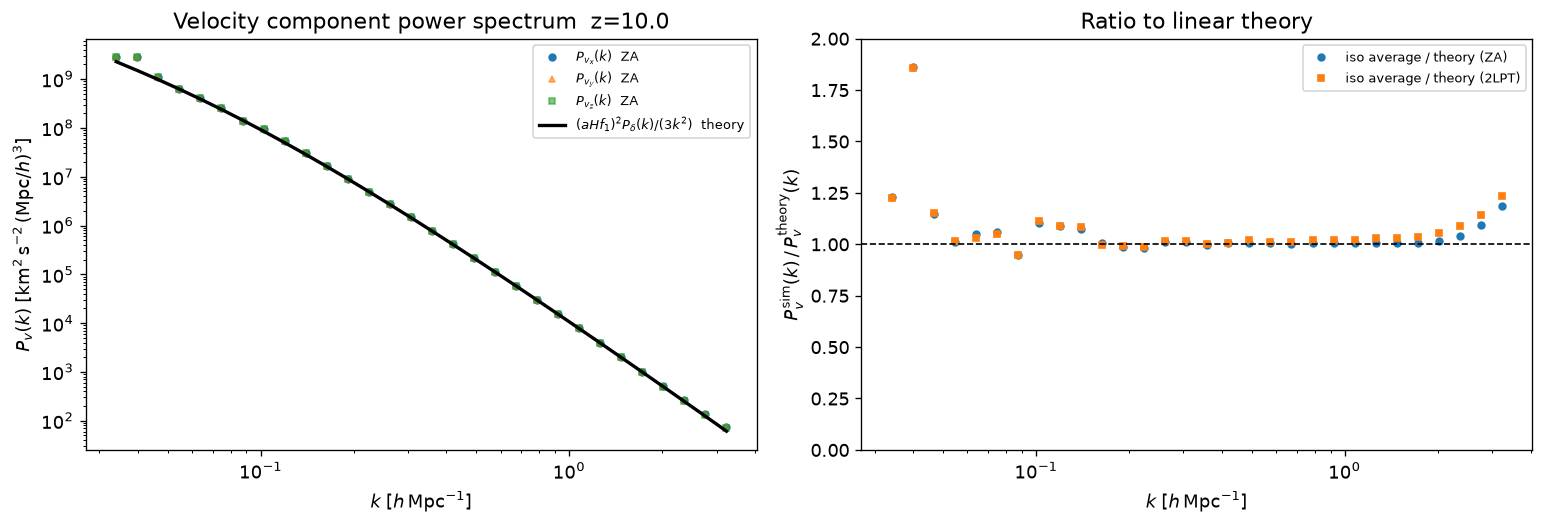

aHf₁ = 186.138 km/s/(Mpc/h)
ZA   P_v large-scale ratio (k<0.3): 1.112
2LPT P_v large-scale ratio (k<0.3): 1.111


In [27]:
# ── Velocity power spectrum vs linear theory ──────────────────────────────────
# Theory for one component: P_vi(k) = (aHf₁/h)² × P_δ(k) / (3k²)
# (isotropic average gives factor 1/3 per component)
aHf = a_z * Hz_nat * f1_num   # km/s/(Mpc/h)

k_vx, Pk_vx = ps1d(vza_x, L)
k_vy, Pk_vy = ps1d(vza_y, L)
k_vz, Pk_vz = ps1d(vza_z, L)
Pk_v_iso    = (Pk_vx + Pk_vy + Pk_vz) / 3   # isotropic average per component

# Theoretical P_vx(k) = (aHf)² P_δ(k) / (3k²)
Pk_v_theory = aHf**2 * eh_nw.P(k_vx, z=z_target) / (3 * k_vx**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.loglog(k_vx, Pk_vx,      'C0o',  ms=4, label=r'$P_{v_x}(k)$  ZA')
ax.loglog(k_vy, Pk_vy,      'C1^',  ms=4, label=r'$P_{v_y}(k)$  ZA', alpha=0.6)
ax.loglog(k_vz, Pk_vz,      'C2s',  ms=4, label=r'$P_{v_z}(k)$  ZA', alpha=0.6)
ax.loglog(k_vx, Pk_v_theory,'k-',   lw=2, label=r'$(aHf_1)^2 P_\delta(k)/(3k^2)$  theory')
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_v(k)\;[\mathrm{km}^2\,\mathrm{s}^{-2}\,(\mathrm{Mpc}/h)^3]$')
ax.set_title(f'Velocity component power spectrum  z={z_target}')
ax.legend(fontsize=8)

ax = axes[1]
ax.semilogx(k_vx, Pk_v_iso   / Pk_v_theory, 'C0o', ms=4, label='iso average / theory (ZA)')
k_v2x, Pk_v2x = ps1d(v2_x, L)
k_v2y, Pk_v2y = ps1d(v2_y, L)
k_v2z, Pk_v2z = ps1d(v2_z, L)
Pk_v2_iso = (Pk_v2x + Pk_v2y + Pk_v2z) / 3
Pk_v2_theory = aHf**2 * eh_nw.P(k_v2x, z=z_target) / (3 * k_v2x**2)
ax.semilogx(k_v2x, Pk_v2_iso / Pk_v2_theory, 'C1s', ms=4, label='iso average / theory (2LPT)')
ax.axhline(1, ls='--', color='k', lw=1)
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_v^\mathrm{sim}(k)\,/\,P_v^\mathrm{theory}(k)$')
ax.set_title('Ratio to linear theory')
ax.legend(fontsize=8)
ax.set_ylim(0, 2)

plt.tight_layout()
plt.show()

print(f'aHf₁ = {aHf:.3f} km/s/(Mpc/h)')
print(f'ZA   P_v large-scale ratio (k<0.3): '
      f'{np.mean((Pk_v_iso / Pk_v_theory)[k_vx < 0.3]):.3f}')
print(f'2LPT P_v large-scale ratio (k<0.3): '
      f'{np.mean((Pk_v2_iso / Pk_v2_theory)[k_v2x < 0.3]):.3f}')

Continuity equation check (ZA):
  ∇·v   rms = 60.2033 km/s/(Mpc/h)
  −aHf δ rms = 60.2033 km/s/(Mpc/h)
  residual rms = 7.67e-14 km/s/(Mpc/h)  (fractional: 1.27e-15)


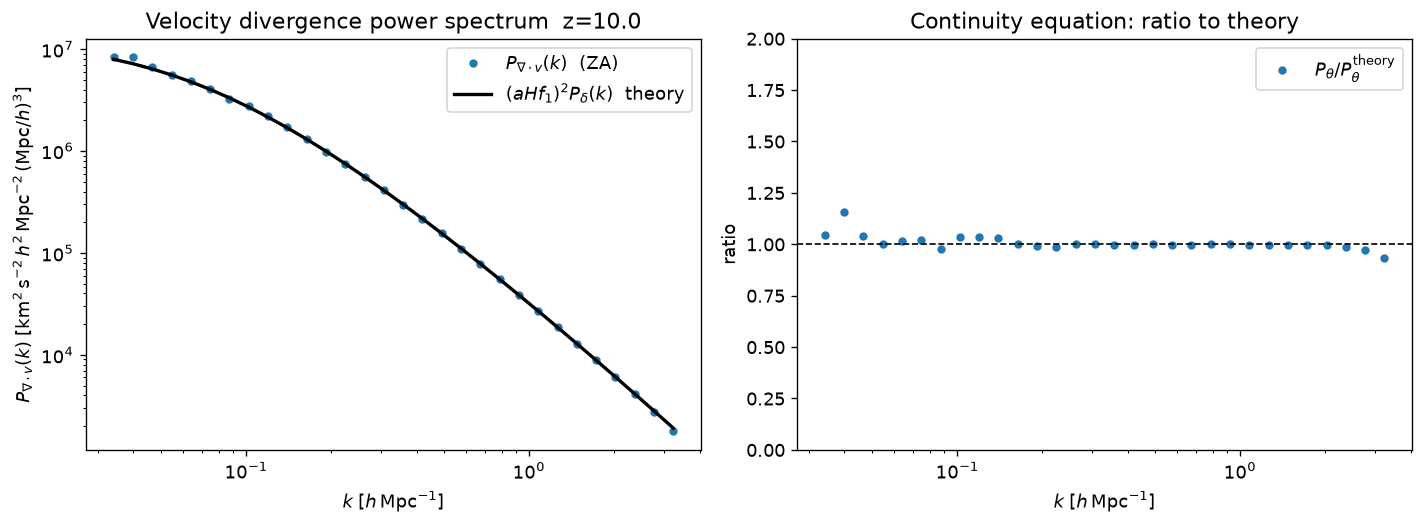

In [28]:
# ── Continuity equation: ∇·v = −aHf δ_linear ─────────────────────────────────
# For ZA, this is exact by construction: v_x(k) = i kx/k² aHf δ(k)
# → ∇·v = irfftn(−k²/k² × aHf δ(k)) = −aHf δ_linear
# Nyquist caveat: a real field cannot carry the odd-derivative (i·k) signal at
# the Nyquist planes — irfftn drops it — so those modes are excluded from the
# comparison on both sides (they hold ~3 % of the rms at 128³).

from beorn.lpt.lpt import _kvectors

kx_g, ky_g, kz_g, k2_g = _kvectors(N, L)
k_ny = np.pi * N / L
m_ny = ((np.abs(np.abs(kx_g) - k_ny) > 1e-9 * k_ny)
        & (np.abs(np.abs(ky_g) - k_ny) > 1e-9 * k_ny)
        & (np.abs(np.abs(kz_g) - k_ny) > 1e-9 * k_ny))

# Compute ∇·v via FFT divergence
Vza_xk = np.fft.rfftn(vza_x)
Vza_yk = np.fft.rfftn(vza_y)
Vza_zk = np.fft.rfftn(vza_z)
div_k  = 1j * kx_g * Vza_xk + 1j * ky_g * Vza_yk + 1j * kz_g * Vza_zk
div_v  = np.fft.irfftn(div_k * m_ny, s=(N, N, N)).real   # ∇·v  [km/s/(Mpc/h)]

# Expected from continuity: −aHf δ_lin(z) = −aHf D₁(z) δ_ic  (delta_ic is normalised at z=0;
# D₁ must be recomputed here — the convergence loop in §5.1 rebinds the name D1)
D1_t = D(1.0 / (1.0 + z_target), param) / D(1.0, param)
expected_div = -aHf * D1_t * np.fft.irfftn(np.fft.rfftn(delta_ic) * m_ny,
                                           s=(N, N, N))

residual = div_v - expected_div
print('Continuity equation check (ZA):')
print(f'  ∇·v   rms = {div_v.std():.4f} km/s/(Mpc/h)')
print(f'  −aHf δ rms = {expected_div.std():.4f} km/s/(Mpc/h)')
print(f'  residual rms = {residual.std():.2e} km/s/(Mpc/h)  '
      f'(fractional: {residual.std()/div_v.std():.2e})')

# Power spectrum of divergence vs theory P_θ(k) = (aHf)² P_δ(k)
k_div, Pk_div = ps1d(div_v, L)
Pk_theta_theory = aHf**2 * eh_nw.P(k_div, z=z_target)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.loglog(k_div, Pk_div,           'C0o', ms=4, label=r'$P_{\nabla\cdot v}(k)$  (ZA)')
ax.loglog(k_div, Pk_theta_theory,  'k-',  lw=2, label=r'$(aHf_1)^2 P_\delta(k)$  theory')
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_{\nabla\cdot v}(k)\;[\mathrm{km}^2\,\mathrm{s}^{-2}\,h^2\,\mathrm{Mpc}^{-2}\,(\mathrm{Mpc}/h)^3]$')
ax.set_title(f'Velocity divergence power spectrum  z={z_target}')
ax.legend()

ax = axes[1]
ax.semilogx(k_div, Pk_div / Pk_theta_theory, 'C0o', ms=4, label=r'$P_\theta / P_\theta^\mathrm{theory}$')
ax.axhline(1, ls='--', color='k', lw=1)
ax.set_ylim(0, 2)
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'ratio')
ax.set_title('Continuity equation: ratio to theory')
ax.legend()

plt.tight_layout()
plt.show()

### 6.1 Validation against 21cmFAST

21cmFAST's `PerturbField.c` computes $v_z = \dot D\,\Psi_z(z{=}0)$ in
Mpc/s (comoving, no factor of $a$); the physical peculiar velocity is
$v\,[\mathrm{km/s}] = v_z\,[\mathrm{Mpc/s}] \times
\mathrm{km/Mpc} \times a(z)$.  We convert and compare against BEoRN's
velocity from the same 21cmFAST GRF (section 4.1).


In [29]:
# ── Velocity field comparison with 21cmFAST ───────────────────────────────────
# 21cmFAST C code (PerturbField.c) computes:
#   v_z = dDdt × Ψ_z(z=0)   [Mpc/s]
# where dDdt = dD/dt [s⁻¹] and Ψ is the ZA displacement in Mpc (BOX_LEN in Mpc).
# This is the comoving velocity — no factor of a.
# Physical peculiar velocity in km/s:
#   v_phys [km/s] = velocity_z [Mpc/s] × km_per_Mpc × a(z)
# where km_per_Mpc = 3.086e19 and a = 1/(1+z).

km_per_Mpc = 3.086e19   # km/Mpc

if _p21cm_available:
    # Discover which velocity attributes exist
    vel_candidates = ['velocity_z', 'velocity_x', 'velocity_y', 'velocity']
    found_vel = {attr: np.asarray(getattr(pf, attr))
                 for attr in vel_candidates if hasattr(pf, attr)}

    if found_vel:
        for attr, v21 in found_vel.items():
            print(f'pf.{attr}: shape={v21.shape}  '
                  f'mean={v21.mean():.4e} Mpc/s  std={v21.std():.4e} Mpc/s')

        # BEoRN velocity from the same 21cmFAST GRF
        vbeo_x, vbeo_y, vbeo_z = za_21cm.get_velocity(z=z_target)

        # Compare LOS (z) component if available
        if 'velocity_z' in found_vel:
            # Convert from Mpc/s to physical km/s: v_phys = v_21cm * km_per_Mpc * a
            v21_z = found_vel['velocity_z'] * km_per_Mpc * a_z

            print(f'\n21cmFAST v_z (converted):  std = {v21_z.std():.3f} km/s')
            print(f'BEoRN     v_z:              std = {vbeo_z.std():.3f} km/s')

            r_v = np.corrcoef(v21_z.ravel(), vbeo_z.ravel())[0, 1]
            print(f'Pixel correlation vz (21cmFAST vs BEoRN): r = {r_v:.4f}')

            # Power spectra
            k_v21z,  Pk_v21z  = ps1d(v21_z,   L)
            k_vbeoz, Pk_vbeoz = ps1d(vbeo_z,  L)
            Pk_vz_th = aHf**2 * eh_nw.P(k_vbeoz, z=z_target) / (3 * k_vbeoz**2)

            fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

            ax = axes[0]
            ax.loglog(k_v21z,  Pk_v21z,  'C0o', ms=4, label='21cmFAST $v_z$ [km/s]')
            ax.loglog(k_vbeoz, Pk_vbeoz, 'C1s', ms=4, label='BEoRN $v_z$ (from 21cmFAST GRF)')
            ax.loglog(k_vbeoz, Pk_vz_th, 'k-',  lw=2,
                      label=r'$(aHf_1)^2 P_\delta/(3k^2)$  theory')
            ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
            ax.set_ylabel(r'$P_{v_z}\;[\mathrm{km}^2\,\mathrm{s}^{-2}\,(\mathrm{Mpc}/h)^3]$')
            ax.set_title(f'LOS velocity power spectrum  z={z_target}')
            ax.legend(fontsize=8)

            ax = axes[1]
            ax.semilogx(k_vbeoz, Pk_vbeoz / Pk_vz_th, 'C1s', ms=4,
                        label='BEoRN / theory')
            ax.semilogx(k_v21z, Pk_v21z / np.interp(k_v21z, k_vbeoz, Pk_vz_th),
                        'C0o', ms=4, label='21cmFAST / theory')
            ax.axhline(1, ls='--', color='k', lw=1)
            ax.set_ylim(0, 2)
            ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
            ax.set_ylabel(r'ratio to theory')
            ax.set_title('21cmFAST vs BEoRN velocity  ratio')
            ax.legend(fontsize=8)

            plt.tight_layout()
            plt.show()

            # Pixel-level comparison slices
            fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
            vlim = np.percentile(np.abs(vbeo_z), 98)
            for ax, field, title in zip(
                axes,
                [v21_z[:, :, sl], vbeo_z[:, :, sl],
                 (vbeo_z - v21_z)[:, :, sl]],
                [f'21cmFAST $v_z$ [km/s]  z={z_target}',
                 f'BEoRN $v_z$ [km/s] (21cmFAST GRF)',
                 r'Residual $v_z^\mathrm{BEoRN} - v_z^\mathrm{21cm}$ [km/s]'],
            ):
                if 'Residual' in title:
                    lim = np.percentile(np.abs(vbeo_z - v21_z), 99)
                    cm = 'RdBu_r'
                else:
                    lim = vlim
                    cm = 'RdBu_r'
                im = ax.imshow(field, origin='lower', cmap=cm,
                               extent=[0, L, 0, L], vmin=-lim, vmax=lim)
                ax.set_title(title)
                ax.set_xlabel('x [Mpc/h]')
                plt.colorbar(im, ax=ax, label='km/s', shrink=0.8)
            axes[0].set_ylabel('y [Mpc/h]')
            plt.tight_layout()
            plt.show()
        else:
            print('velocity_z not found; available:', list(found_vel.keys()))
            print('Plotting BEoRN velocity power spectrum only.')
            k_vbeoz, Pk_vbeoz = ps1d(vbeo_z, L)
            Pk_vz_th = aHf**2 * eh_nw.P(k_vbeoz, z=z_target) / (3 * k_vbeoz**2)
            fig, ax = plt.subplots(figsize=(6, 4))
            ax.loglog(k_vbeoz, Pk_vbeoz, 'C1s', ms=4, label='BEoRN $v_z$')
            ax.loglog(k_vbeoz, Pk_vz_th, 'k-',  lw=2, label='theory')
            ax.legend(); plt.tight_layout(); plt.show()
    else:
        print('No velocity attributes found on PerturbedField.')
        print('py21cmfast may not expose velocity in this version.')
else:
    print('(py21cmfast not installed — skipping velocity comparison)')
    print()
    print('Expected outcomes when py21cmfast is available:')
    print('  • std(v21_z) ≈ std(vbeo_z) after unit conversion (km/s)')
    print('  • Pixel correlation r > 0.95 (21cmFAST 2LPT vs BEoRN 1LPT will show small offset)')
    print('  • P_vz(k) from both codes matches (aHf)² P(k) / (3k²) at k < 0.5 h/Mpc')
    print('  • Residual ~5–10 % due to 2LPT correction in 21cmFAST (USE_2LPT=True)')
    print('  • Unit note: velocity_z [Mpc/s] × km_per_Mpc × a → physical km/s')

(py21cmfast not installed — skipping velocity comparison)

Expected outcomes when py21cmfast is available:
  • std(v21_z) ≈ std(vbeo_z) after unit conversion (km/s)
  • Pixel correlation r > 0.95 (21cmFAST 2LPT vs BEoRN 1LPT will show small offset)
  • P_vz(k) from both codes matches (aHf)² P(k) / (3k²) at k < 0.5 h/Mpc
  • Residual ~5–10 % due to 2LPT correction in 21cmFAST (USE_2LPT=True)
  • Unit note: velocity_z [Mpc/s] × km_per_Mpc × a → physical km/s


### 6.2 GPU acceleration test

Velocities reuse the cached k-space sources, so the GPU path is the same
3-iFFT combine with the velocity coefficients $a H f_n D_n$.


In [30]:
if _TORCH_AVAILABLE and torch_gpu is not None:
    vg_x, vg_y, vg_z = s_gpu.get_velocity(z_target)   # 2LPT GPU solver (§5.2)
    print(f'2LPT velocity torch-{torch_gpu} vs numpy: max|Δv|/std = '
          f'{np.max(np.abs(vg_x - v2_x)) / v2_x.std():.2e}'
          + ('  (float32 on MPS)' if torch_gpu == 'mps' else ''))
    t_cpu = bench(lambda: lpt2.get_velocity(z_target), n=3)
    t_gpu = bench(lambda: s_gpu.get_velocity(z_target), n=3)
    print(f'get_velocity {N}³:  numpy {t_cpu*1e3:6.0f} ms   '
          f'torch-{torch_gpu} {t_gpu*1e3:6.0f} ms   ({t_cpu/t_gpu:.1f}×)')
else:
    print('GPUs not available — velocity GPU test skipped.')


2LPT velocity torch-cuda vs numpy: max|Δv|/std = 2.28e-15
get_velocity 128³:  numpy     37 ms   torch-cuda      1 ms   (32.1×)


### 6.3 Autodiff test: growth rate and dP̂(k)/dθ of the velocity field

Two gradient paths: (i) the growth rate $f_1 = d\ln D_1/d\ln a$ by exact
autodiff of the growth integral (`f1_method='autodiff'`), and (ii) the
measured LOS-velocity power spectrum differentiated through
$v_z = a\,H(\theta)\,f_1(\theta)\,\Psi_z$ — note $f_1$ itself is
obtained by *nested* autodiff inside the differentiated pipeline.  (No
dashed linear reference here: $P_{v_z} \propto (aHf_1)^2 P_\delta/k^2$
carries extra θ-dependence through $aHf_1$, so the density-field comparison
does not apply.)


In [31]:
# ── Growth rate by exact autodiff (f1_method='autodiff') ─────────────────────
# The default f₁ is a finite difference through cosmo.D (~1e-3–1e-4 floor).
# beorn.cosmo.growth_rate differentiates the fixed-node growth integral
# exactly; LPT solvers accept f1_method='autodiff' to use it in get_velocity.
if _JAX or _TORCH_AVAILABLE:
    from beorn.cosmo import growth_rate
    be8 = 'jax' if _JAX else 'torch'
    f1_ad = float(growth_rate(1.0 / (1.0 + z_target), param.cosmology.Om, backend=be8))
    print(f'f₁ exact autodiff ({be8}) = {f1_ad:.6f}')
    print(f'f₁ finite difference     = {f1_num:.6f}   (solver default, f1_method="fd")')
    print(f'f₁ Linder Ωm(z)^0.55     = {f1_linder:.6f}')
    za_ad = lpt.ZeldovichApproximation(param, seed=SEED, verbose=False,
                                       f1_method='autodiff')
    vx_ad, _, _ = za_ad.get_velocity(z_target)
    print(f'ZA velocity rms with autodiff f₁: {vx_ad.std():.4f} km/s   '
          f'(fd: {vza_x.std():.4f} km/s)')
else:
    print('JAX/torch is not installed — autodiff growth rate skipped.')

f₁ exact autodiff (jax) = 0.999110
f₁ finite difference     = 0.999143   (solver default, f1_method="fd")
f₁ Linder Ωm(z)^0.55     = 0.999103
ZA velocity rms with autodiff f₁: 112.0378 km/s   (fd: 112.0416 km/s)


velocity v_z: dP̂/dσ₈ jacfwd vs FD — max rel err = 7.10e-12


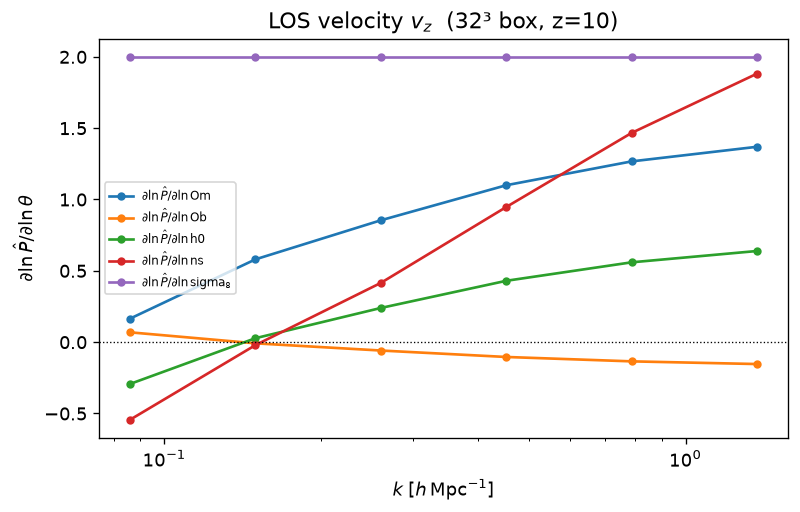

In [32]:
if _JAX:
    def field_vz_diff(theta):
        dkd = delta_k_of(theta)
        pz = jnp.fft.irfftn(1j * kzj * ik2j * dkd, s=(Nd,)*3)
        Om = theta[0]
        f1d = growth_rate(ad, Om, backend='jax')       # nested autodiff
        return ad * 100.0 * hubble_E(zd, Om, backend='jax') * f1d * pz  # km/s

    J_vz, P0_vz = jac_Phat(field_vz_diff)
    print(f'velocity v_z: dP̂/dσ₈ jacfwd vs FD — max rel err = '
          f'{fd_check(field_vz_diff, J_vz):.2e}')
    fig, ax = plt.subplots(figsize=(6.8, 4.4))
    plot_dlogP(ax, J_vz, P0_vz,
               f'LOS velocity $v_z$  ({Nd}³ box, z={zd:.0f})')
    plt.tight_layout()
    plt.show()
else:
    print('JAX is not installed — velocity autodiff demo skipped.')


---
<a id="sec7"></a>
## 7. Halo catalogue generation from the conditional HMF

[`LPTHaloLoader`](../src/beorn/load_input_data/lpt_loader.py) pairs the
Zel'dovich Approximation with a [`CHMFSampler`](../src/beorn/lpt/chmf.py) to
generate halo catalogs via the **Extended Press-Schechter conditional HMF**
(Bond et al. 1991; Lacey & Cole 1993):

$$\frac{dn}{d\ln M}\bigg|_\delta = \frac{\rho_m}{M}\left|\frac{d\ln\sigma_\mathrm{eff}}{d\ln M}\right| f_\mathrm{PS}(\nu_\mathrm{eff})$$

where $\sigma_\mathrm{eff}^2(M) = \sigma^2(M) - \sigma^2(M_\mathrm{env})$
is the conditional variance and
$\nu_\mathrm{eff} = (\delta_c - \delta_\mathrm{env}) / \sigma_\mathrm{eff}$.

**Key design choice:** conditioning uses the *linear* density field
$\delta_\mathrm{lin} = \mathcal{F}^{-1}[D_1(z)\,\delta(\mathbf{k})\,W_\mathrm{th}(k R_\mathrm{env})]$
rather than the CIC-painted field.  CIC density has shot-noise tails
($\max\delta \approx 2.5$ vs Gaussian expectation $\approx 1.2$) that
blow up the CHMF near $M_\mathrm{env}$ where $\sigma_\mathrm{eff} \to 0$.

Per-cell Poisson sampling of this CHMF is the **default** halo-generation
algorithm; the differentiable expected-number alternative is demonstrated in
sections 7.3 and 7.5.


In [33]:
from beorn.load_input_data import LPTHaloLoader

# 64³ grid, 200 Mpc/h box: good halo statistics, ~10 s per snapshot
param_chmf = Parameters()
param_chmf.simulation.Ncell = 64
param_chmf.simulation.Lbox  = 200.0   # Mpc/h
param_chmf.simulation.use_hunits = True  # Lbox above is in Mpc/h, not physical Mpc
param_chmf.simulation.oversample = 1  # explicit default: no fine-paint-then-downsample (see LPTBase.get_density)
param_chmf.simulation.backend.default = 'numpy'  # explicit default: keeps this as the numpy reference used throughout for numpy-vs-jax/torch comparisons below
param_chmf.cosmo_sim.snapshot_redshifts = np.array([6.0, 8.0, 10.0])

# LPTHaloLoader: ZA solver + CHMFSampler (EPS conditional HMF)
loader = LPTHaloLoader(param_chmf, seed=42, n_mass_bins=40)
chmf   = loader.sampler.chmf   # for analytical PS reference

cell_c = param_chmf.simulation.Lbox / param_chmf.simulation.Ncell
M_env  = chmf.rho_m * cell_c**3
print(f'Cell size : {cell_c:.2f} Mpc/h')
print(f'R_tophat  : {loader._R_tophat:.4f} Mpc/h  (sphere-equivalent cell radius)')
print(f'M_env     : {M_env:.2e} Msun  (CHMF valid for M < M_env)\n')

catalogs = {}
for i, z in enumerate(param_chmf.cosmo_sim.snapshot_redshifts):
    cat = loader.load_halo_catalog(i)
    catalogs[z] = cat
    print(f'z={z:.1f}:  {cat.size:,} halos   '
          f'M = [{cat.masses.min():.2e}, {cat.masses.max():.2e}] Msun')

Cell size : 3.12 Mpc/h
R_tophat  : 1.9386 Mpc/h  (sphere-equivalent cell radius)
M_env     : 3.96e+12 Msun  (CHMF valid for M < M_env)



z=6.0:  277,143,190 halos   M = [1.14e+08, 2.04e+12] Msun
z=8.0:  143,187,067 halos   M = [1.14e+08, 7.09e+11] Msun
z=10.0:  57,310,869 halos   M = [1.14e+08, 1.89e+11] Msun


### 7.1 Halo mass function: model vs generated catalogues

Volume-averaging the CHMF over all cells of the LPT density field must
recover the unconditional PS HMF — the defining property of EPS.  We compare
the HMF measured from the sampled catalogues against the PS prediction.


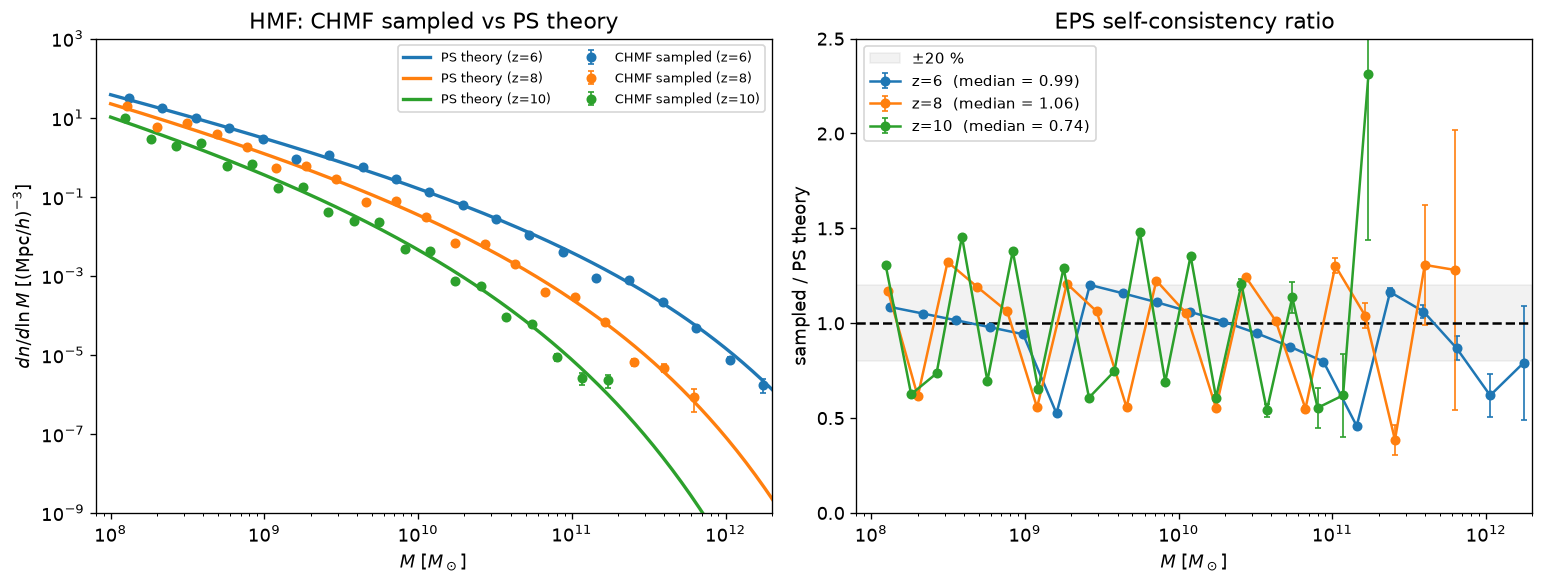

In [34]:
M_plot = np.logspace(8, 14, 300)
colors = ['C0', 'C1', 'C2']
n_bins = 20

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for (z, cat), color in zip(sorted(catalogs.items()), colors):
    # Analytical PS HMF
    hmf_ps = chmf.hmf_ps(M_plot, z)
    axes[0].loglog(M_plot, hmf_ps, '-', color=color, lw=2,
                   label=f'PS theory (z={z:.0f})')

    # Measured HMF from sampled catalog
    bin_edges, hmf_meas, hmf_err = cat.halo_mass_function(bin_count=n_bins)
    M_bins = np.sqrt(bin_edges[:-1] * bin_edges[1:])
    mask = hmf_meas > 0
    axes[0].errorbar(M_bins[mask], hmf_meas[mask], yerr=hmf_err[mask],
                     fmt='o', color=color, ms=5, elinewidth=1, capsize=2,
                     label=f'CHMF sampled (z={z:.0f})')

    # EPS self-consistency: ratio of sampled to analytical HMF
    hmf_interp = np.interp(M_bins[mask], M_plot, hmf_ps)
    ratio      = hmf_meas[mask] / hmf_interp
    ratio_err  = hmf_err[mask]  / hmf_interp
    axes[1].errorbar(M_bins[mask], ratio, yerr=ratio_err,
                     fmt='o-', color=color, ms=5, elinewidth=1, capsize=2,
                     label=f'z={z:.0f}  (median = {np.median(ratio):.2f})')

axes[0].set_xlabel(r'$M\;[M_\odot]$')
axes[0].set_ylabel(r'$dn/d\ln M\;[(\mathrm{Mpc}/h)^{-3}]$')
axes[0].set_title('HMF: CHMF sampled vs PS theory')
axes[0].legend(fontsize=8, ncol=2)
axes[0].set_ylim(1e-9, 1e3)
axes[0].set_xlim(8e7, 2e12)

axes[1].axhline(1.0, ls='--', color='k', lw=1.5)
axes[1].axhspan(0.8, 1.2, alpha=0.1, color='grey', label='±20 %')
axes[1].set_xlabel(r'$M\;[M_\odot]$')
axes[1].set_ylabel('sampled / PS theory')
axes[1].set_title('EPS self-consistency ratio')
axes[1].set_xscale('log')
axes[1].set_ylim(0, 2.5)
axes[1].set_xlim(8e7, 2e12)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 7.2 Gridded halo-mass maps vs density maps

NGP-paint the total halo mass of the catalogue onto the grid and compare
with the CIC matter density: halos must trace the large-scale structure,
with amplified contrast (halo bias).


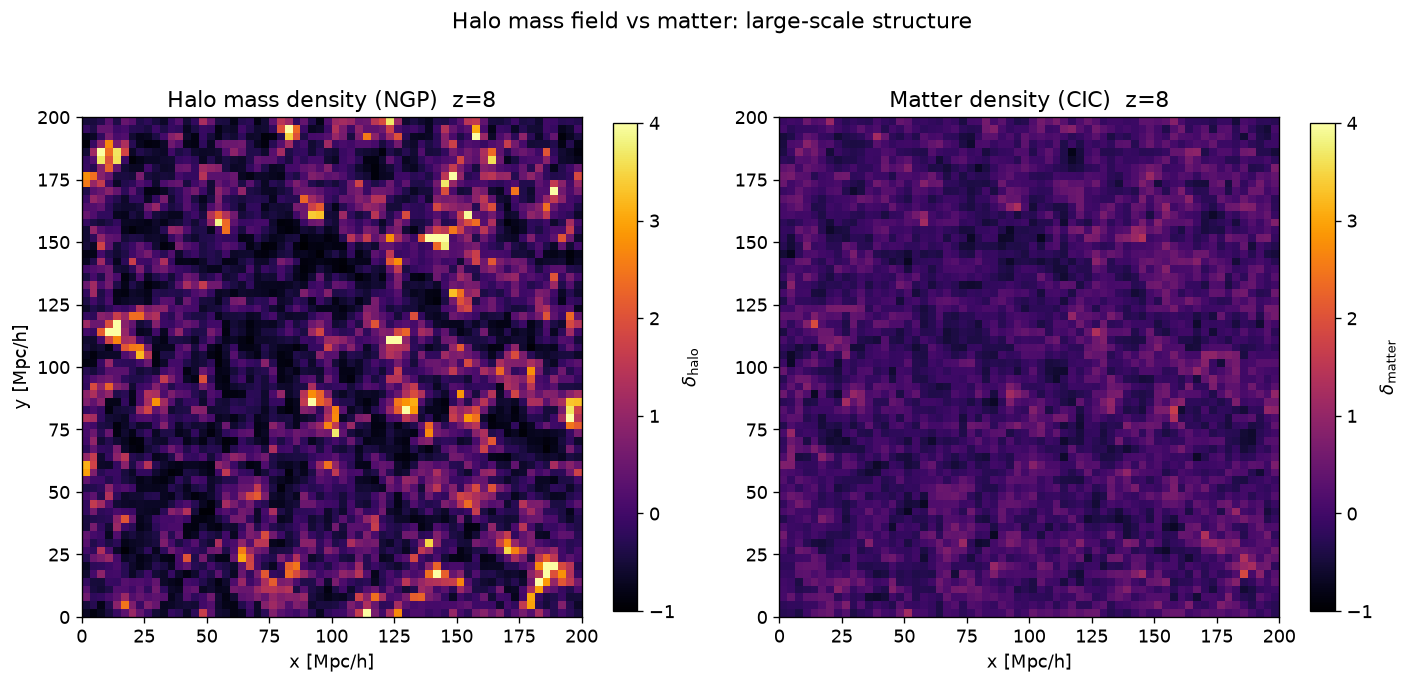

Pixel correlation  δ_halo vs δ_matter = 0.530
Halo mass field:  max=12.2   std=0.778
Matter field:     max=2.349   std=0.315


In [35]:
# ── Halo mass density vs matter density: large-scale structure comparison ──────
z_show    = 8.0
cat_show  = catalogs[z_show]
delta_cic = loader.lpt_solver.get_density(z_show)

N_c, L_c = param_chmf.simulation.Ncell, param_chmf.simulation.Lbox
sl_c = N_c // 2

# NGP-paint total halo mass onto the same grid
bins = np.linspace(0, L_c, N_c + 1)
rho_halo, _ = np.histogramdd(
    cat_show.positions % L_c,      # wrap periodic boundaries
    bins=[bins, bins, bins],
    weights=cat_show.masses,
)
delta_hm = (rho_halo - rho_halo.mean()) / rho_halo.mean()   # halo mass overdensity

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

vmin, vmax = -1, 4
im0 = axes[0].imshow(delta_hm[:, :, sl_c], origin='lower', cmap='inferno',
                     extent=[0, L_c, 0, L_c], vmin=vmin, vmax=vmax)
axes[0].set_title(f'Halo mass density (NGP)  z={z_show:.0f}')
axes[0].set_xlabel('x [Mpc/h]')
axes[0].set_ylabel('y [Mpc/h]')
fig.colorbar(im0, ax=axes[0], label=r'$\delta_\mathrm{halo}$', shrink=0.85)

im1 = axes[1].imshow(delta_cic[:, :, sl_c], origin='lower', cmap='inferno',
                     extent=[0, L_c, 0, L_c], vmin=vmin, vmax=vmax)
axes[1].set_title(f'Matter density (CIC)  z={z_show:.0f}')
axes[1].set_xlabel('x [Mpc/h]')
fig.colorbar(im1, ax=axes[1], label=r'$\delta_\mathrm{matter}$', shrink=0.85)

fig.suptitle('Halo mass field vs matter: large-scale structure', y=1.01)
plt.tight_layout()
plt.show()

r_hm = np.corrcoef(delta_hm.ravel(), delta_cic.ravel())[0, 1]
print(f'Pixel correlation  δ_halo vs δ_matter = {r_hm:.3f}')
print(f'Halo mass field:  max={delta_hm.max():.1f}   std={delta_hm.std():.3f}')
print(f'Matter field:     max={delta_cic.max():.3f}   std={delta_cic.std():.3f}')

### 7.3 Expected-number mode: noiseless EPS self-consistency

`CHMFSampler.expected_counts` returns the per-cell, per-mass-bin expected
halo count λ_b — the intensity field the Poisson sampler draws from.
Averaging it over cells tests EPS self-consistency *without sampling noise*,
and it is the building block for differentiable expected-number painting.


Σλ = 143,185,829 expected halos   vs   143,187,067 sampled (ratio 1.0000, Poisson noise ~0.0%)


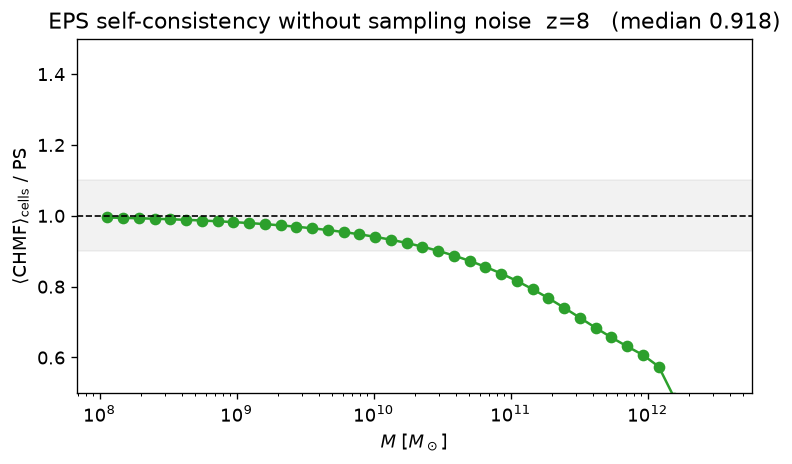

In [36]:
# ── Expected-number mode: the dense Poisson intensity λ_b(cell) ──────────────
# CHMFSampler.expected_counts returns the per-cell, per-mass-bin expected halo
# count — the field the Poisson sampler draws from. Averaging it over cells
# tests EPS self-consistency *without sampling noise*, and it is the building
# block for differentiable expected-number painting.
delta_lin_show = loader.lpt_solver.get_linear_density(z_show, R_tophat=loader._R_tophat)
Mc, lam = loader.sampler.expected_counts(delta_lin_show, z_show, n_mass_bins=40)   # same bins as the sampler
print(f'Σλ = {lam.sum():,.0f} expected halos   vs   {catalogs[z_show].size:,} sampled '
      f'(ratio {catalogs[z_show].size/lam.sum():.4f}, Poisson noise ~{1/np.sqrt(lam.sum()):.1%})')

dlnM_b = np.log(Mc[1] / Mc[0])
mean_dndlnm = lam.mean(axis=(1, 2, 3)) / (dlnM_b * cell_c**3)
ratio = mean_dndlnm / chmf.hmf_ps(Mc, z_show)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.semilogx(Mc, ratio, 'o-', color='C2')
ax.axhline(1, ls='--', color='k', lw=1)
ax.axhspan(0.9, 1.1, alpha=0.1, color='grey')
ax.set_xlabel(r'$M\;[M_\odot]$')
ax.set_ylabel(r'$\langle$CHMF$\rangle_\mathrm{cells}$ / PS')
ax.set_title(f'EPS self-consistency without sampling noise  z={z_show:.0f}   '
             f'(median {np.median(ratio):.3f})')
ax.set_ylim(0.5, 1.5)
plt.tight_layout()
plt.show()

### 7.4 GPU acceleration test

`conditional_dndlnm_diff` is backend-generic; on torch it runs on the GPU
(float32 on Apple MPS).  We check parity against numpy and time the
conditional-HMF evaluation over the full grid.


In [37]:
from beorn.lpt import conditional_dndlnm_diff

c9 = param_chmf.cosmology
cos9 = dict(Om=c9.Om, Ob=c9.Ob, h0=c9.h0, ns=c9.ns, sigma_8=c9.sigma_8)
M_test = 1e10
n_np = conditional_dndlnm_diff(M_test, delta_lin_show.astype(np.float64),
                               M_env, z_show, **cos9)

if _TORCH_AVAILABLE and torch_gpu is not None:
    dt_dev = torch.float32 if torch_gpu == 'mps' else torch.float64
    d_dev = torch.as_tensor(delta_lin_show, dtype=dt_dev, device=torch_gpu)
    n_dev = conditional_dndlnm_diff(M_test, d_dev, M_env, z_show,
                                    backend='torch', **cos9)
    n_gpu = n_dev.cpu().double().numpy()
    mask = n_np > 1e-30 * n_np.max()
    print(f'conditional_dndlnm_diff torch-{torch_gpu} vs numpy: '
          f'median|ratio-1| = {np.median(np.abs(n_gpu[mask]/n_np[mask] - 1)):.2e}'
          + ('  (float32 on MPS)' if torch_gpu == 'mps' else ''))
    sync = (torch.mps.synchronize if torch_gpu == 'mps'
            else torch.cuda.synchronize)
    t_np = bench(lambda: conditional_dndlnm_diff(
        M_test, delta_lin_show.astype(np.float64), M_env, z_show, **cos9), n=3)

    def run_dev():
        conditional_dndlnm_diff(M_test, d_dev, M_env, z_show,
                                backend='torch', **cos9)
        sync()

    t_dev = bench(run_dev, n=3)
    Nc_ = param_chmf.simulation.Ncell
    print(f'conditional HMF on the {Nc_}³ field:  numpy {t_np*1e3:6.0f} ms   '
          f'torch-{torch_gpu} {t_dev*1e3:6.0f} ms   ({t_np/t_dev:.1f}×)')
else:
    print('GPUs not available — conditional-HMF GPU test skipped.')


conditional_dndlnm_diff torch-cuda vs numpy: median|ratio-1| = 3.38e-14
conditional HMF on the 64³ field:  numpy      2 ms   torch-cuda      2 ms   (1.0×)


### 7.5 Autodiff test: conditional-HMF gradients and dP̂(k)/dθ of the halo-mass grid

Gradients w.r.t. the cosmology **and** the conditioning density field, then
the full differentiable halo pipeline:
θ → δ_lin → expected-number painting $\sum_b M_b\,\lambda_b$ →
halo-mass overdensity → measured $\hat P$ → jacobian.  Dashed lines:
linear-field gradients — the amplified response is the halo bias.


conditional_dndlnm_diff vs class: max|ratio-1| = 1.13e-03   (class uses interp table + 1% FD)
d(Σ dn/dlnM)/dσ₈:  jax = +7.1662e+04   FD = +7.1662e+04   rel err = 6.66e-12


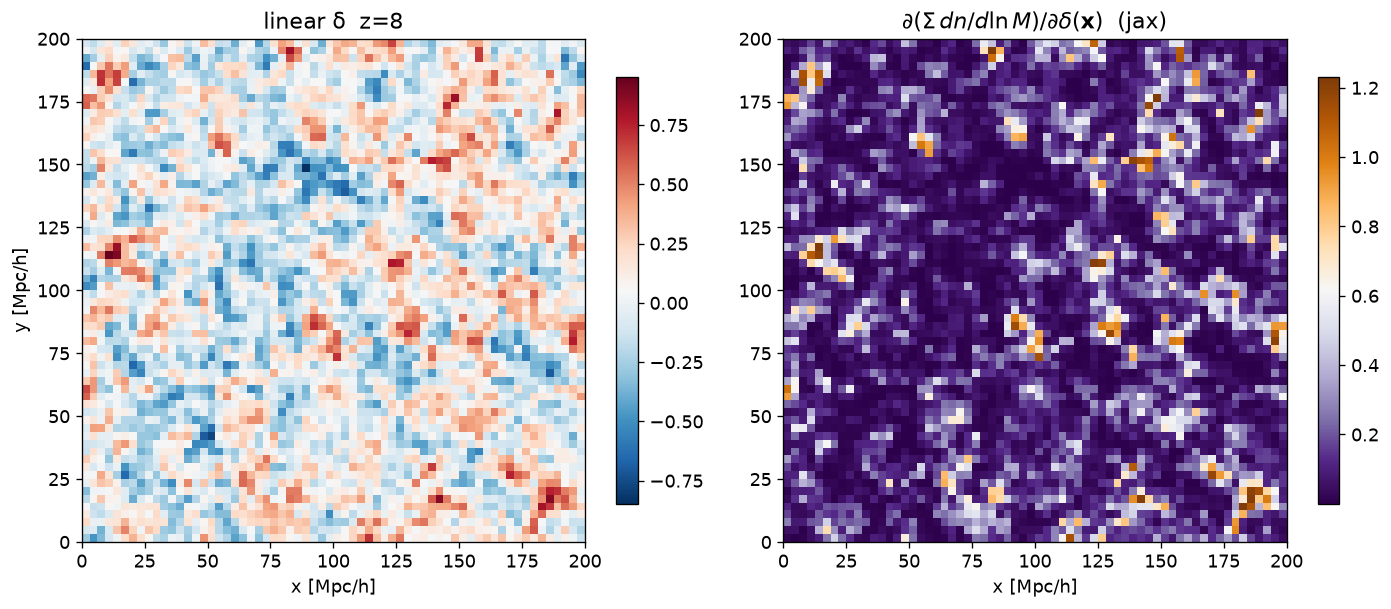

torch field-gradient vs jax: max rel diff = 7.77e-14


In [38]:
# ── Differentiable conditional HMF: gradients w.r.t. cosmology AND the field ──
# conditional_dndlnm_diff is the backend-generic pure-function counterpart of
# CHMF.hmf_chmf_field: sigma² from the direct backend integral, analytic
# d ln(σ_eff)/d lnM. It is differentiable through the cosmology and through
# the conditioning density field itself — the gradient path from halo
# abundances back to the LPT field.
n_class = chmf.hmf_chmf_field(M_test, delta_lin_show.astype(np.float64),
                              float(chmf.sigma2(M_env, z_show)), z_show)
print(f'conditional_dndlnm_diff vs class: max|ratio-1| = '
      f'{np.max(np.abs(n_np / np.maximum(n_class, 1e-300) - 1)[n_class > 0]):.2e}'
      '   (class uses interp table + 1% FD)')

if _JAX:
    d64 = jnp.asarray(delta_lin_show.astype(np.float64))
    # gradient of the total expected abundance w.r.t. sigma_8
    g_s8 = jax.grad(lambda s8: conditional_dndlnm_diff(
        M_test, d64, M_env, z_show, c9.Om, c9.Ob, c9.h0, c9.ns, s8,
        backend='jax').sum())(c9.sigma_8)
    eps = 1e-6
    fd = (conditional_dndlnm_diff(M_test, delta_lin_show, M_env, z_show,
                                  c9.Om, c9.Ob, c9.h0, c9.ns, c9.sigma_8 + eps).sum()
          - conditional_dndlnm_diff(M_test, delta_lin_show, M_env, z_show,
                                    c9.Om, c9.Ob, c9.h0, c9.ns, c9.sigma_8 - eps).sum()) / (2 * eps)
    print(f'd(Σ dn/dlnM)/dσ₈:  jax = {float(g_s8):+.4e}   FD = {fd:+.4e}   '
          f'rel err = {abs(float(g_s8)/fd - 1):.2e}')

    # gradient w.r.t. the density field: where does abundance respond to matter?
    g_field = jax.grad(lambda d: conditional_dndlnm_diff(
        M_test, d, M_env, z_show, backend='jax', **cos9).sum())(d64)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    im0 = axes[0].imshow(delta_lin_show[:, :, sl_c], origin='lower', cmap='RdBu_r',
                         extent=[0, L_c, 0, L_c])
    axes[0].set_title(f'linear δ  z={z_show:.0f}')
    plt.colorbar(im0, ax=axes[0], shrink=0.8)
    im1 = axes[1].imshow(np.asarray(g_field)[:, :, sl_c], origin='lower', cmap='PuOr_r',
                         extent=[0, L_c, 0, L_c])
    axes[1].set_title(r'$\partial (\Sigma\, dn/d\ln M) / \partial \delta(\mathbf{x})$  (jax)')
    plt.colorbar(im1, ax=axes[1], shrink=0.8)
    for ax in axes:
        ax.set_xlabel('x [Mpc/h]')
    axes[0].set_ylabel('y [Mpc/h]')
    plt.tight_layout()
    plt.show()
else:
    print('JAX is not installed — skipping the conditional-HMF gradient demo.')

if _TORCH_AVAILABLE and _JAX:
    dt = torch.as_tensor(delta_lin_show, dtype=torch.float64).requires_grad_(True)
    conditional_dndlnm_diff(M_test, dt, M_env, z_show, backend='torch',
                            **cos9).sum().backward()
    print(f'torch field-gradient vs jax: max rel diff = '
          f'{np.max(np.abs(dt.grad.numpy() / np.asarray(g_field) - 1)):.2e}')
elif not _TORCH_AVAILABLE:
    print('torch is not installed — torch cross-check skipped.')

halo-mass grid: dP̂/dσ₈ jacfwd vs FD — max rel err = 7.40e-08


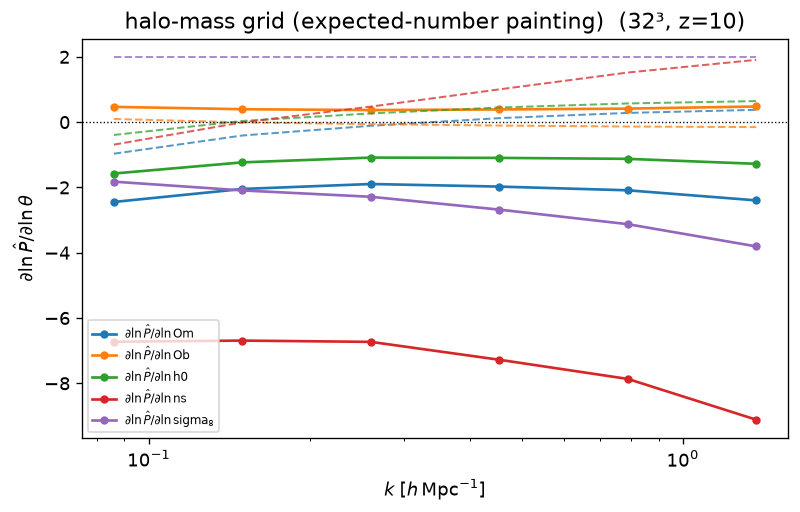

Dashed: linear-field gradients — the amplified response is the halo bias: σ₈/Ωₘ shifts move the exponential EPS tail much faster than the linear P(k).


In [39]:
if _JAX:
    from beorn.constants import rhoc0

    M_env_d = float(cosmo.Om * rhoc0 / cosmo.h0 * cell_d**3)
    M_edges_d = np.logspace(9, np.log10(0.9 * M_env_d), 11)
    Mc_d = np.sqrt(M_edges_d[:-1] * M_edges_d[1:])
    dln_d = np.diff(np.log(M_edges_d))

    def field_halomass_diff(theta):
        Om, Ob, h0v, nsv, s8v = theta
        dlin = jnp.fft.irfftn(delta_k_of(theta) * Wthj, s=(Nd,)*3)
        M_env_t = Om * rhoc0 / h0v * cell_d**3
        fld = jnp.zeros((Nd,)*3)
        for M_b, dl in zip(Mc_d, dln_d):       # expected-number painting
            n_b = conditional_dndlnm_diff(M_b, dlin, M_env_t, zd,
                                          Om, Ob, h0v, nsv, s8v, backend='jax')
            fld = fld + M_b * n_b * dl * cell_d**3
        return fld / fld.mean() - 1.0

    J_hm, P0_hm = jac_Phat(field_halomass_diff)
    print(f'halo-mass grid: dP̂/dσ₈ jacfwd vs FD — max rel err = '
          f'{fd_check(field_halomass_diff, J_hm):.2e}')
    fig, ax = plt.subplots(figsize=(6.8, 4.4))
    plot_dlogP(ax, J_hm, P0_hm,
               f'halo-mass grid (expected-number painting)  ({Nd}³, z={zd:.0f})',
               ref=dlogP_linear)
    plt.tight_layout()
    plt.show()
    print('Dashed: linear-field gradients — the amplified response is the '
          'halo bias: σ₈/Ωₘ shifts move the exponential EPS tail much faster '
          'than the linear P(k).')
else:
    print('JAX is not installed — halo-grid autodiff demo skipped.')
